# Análisis y Predicción de los Comparendos Electrónicos en Barranquilla

In [908]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

from IPython.display import display
from IPython.display import HTML
from plotly.subplots import make_subplots

## Carga del archivo de comparendos electrónicos

Se carga el archivo CSV que contiene los datos de comparendos electrónicos utilizando la función `read_csv` de la librería pandas, y se almacena en el DataFrame `df_comparendos_electronicos`.

In [909]:
df_comparendos_electronicos = pd.read_csv("C:/Users/david/Documents/seminario_investigativo/comparendos_electronicos.csv")

## Visualización inicial del DataFrame

Se muestra una vista previa de las primeras filas del DataFrame `df_comparendos_electronicos` utilizando el método `head()`, lo que permite inspeccionar la estructura y los primeros registros de los datos cargados.

In [910]:
df_comparendos_electronicos.head()

,fecha_comparendo,COD_INFRACCION,DESC_INFRACCION,TIPO_INFRACCION,SERVICIO_VEHICULO_INFRACTOR,CLASE_VEHICULO_INFRACTOR,CANTIDAD_INFRACCIONES,Tipo Camara,Camara_y_direccion
0,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,AUTOMOVIL,4,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
1,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,2,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
2,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,1,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 31
3,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,AUTOMOVIL,2,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 9G
4,2018 Jan 01 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,3,Fijo,AVENIDA CIRCUNVALAR CON CARRERA 9G


Se presentan las últimas filas del DataFrame `df_comparendos_electronicos` mediante el método `tail()`, permitiendo verificar los registros finales y confirmar la correcta carga completa de los datos.

In [911]:
df_comparendos_electronicos.tail()

,fecha_comparendo,COD_INFRACCION,DESC_INFRACCION,TIPO_INFRACCION,SERVICIO_VEHICULO_INFRACTOR,CLASE_VEHICULO_INFRACTOR,CANTIDAD_INFRACCIONES,Tipo Camara,Camara_y_direccion
339611,2025 Dec 31 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMPERO,1,Fijo,CARRERA 46 CON CALLE 100
339612,2025 Dec 31 12:00:00 AM,C29,Conducir un vehículo a velocidad superior a la...,TRÁNSITO,PARTICULAR,CAMIONETA,1,Fijo,CARRERA 53 ENTRE CALLE 104 Y 106
339613,2025 Dec 31 12:00:00 AM,D04,No detenerse ante luz roja o amarilla de semáf...,TRÁNSITO,PARTICULAR,MOTOCICLETA,2,Fijo,CALLE 45 CON CARRERA 21 SENTIDO NORTE-SUR
339614,2025 Dec 31 12:00:00 AM,D04,No detenerse ante luz roja o amarilla de semáf...,TRÁNSITO,PARTICULAR,CAMPERO,1,Fijo,CARRERA 53 ENTRE CALLE 104 Y 106
339615,2025 Dec 31 12:00:00 AM,D04,No detenerse ante luz roja o amarilla de semáf...,TRÁNSITO,PARTICULAR,MOTOCICLETA,3,Fijo,CARRERA 53 ENTRE CALLE 104 Y 106


## Información general del DataFrame

Se utiliza el método `info()` para obtener un resumen de la estructura del DataFrame, incluyendo el número de entradas, los nombres de las columnas, los tipos de datos y la cantidad de valores no nulos, lo que facilita la identificación de posibles valores faltantes y la verificación de la integridad de los datos.

In [912]:
df_comparendos_electronicos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 339616 entries, 0 to 339615
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype 
---  ------                       --------------   ----- 
 0   fecha_comparendo             339616 non-null  object
 1   COD_INFRACCION               339616 non-null  object
 2   DESC_INFRACCION              339052 non-null  object
 3   TIPO_INFRACCION              339616 non-null  object
 4   SERVICIO_VEHICULO_INFRACTOR  339616 non-null  object
 5   CLASE_VEHICULO_INFRACTOR     339616 non-null  object
 6   CANTIDAD_INFRACCIONES        339616 non-null  int64 
 7   Tipo Camara                  339616 non-null  object
 8   Camara_y_direccion           339616 non-null  object
dtypes: int64(1), object(8)
memory usage: 23.3+ MB


El DataFrame `df_comparendos_electronicos` contiene **339,616 registros** (desde el índice 0 hasta el 339,615) y está compuesto por **9 columnas**. Las variables son mayoritariamente de tipo `object` (categóricas o texto), con una única columna numérica (`CANTIDAD_INFRACCIONES`) de tipo `int64`.


**Aspectos destacados:**

- **Volumen de datos**: Se cuenta con una base de datos robusta de más de 339 mil comparendos electrónicos, lo que permite realizar análisis estadísticos representativos.
- **Valores nulos**: La columna `DESC_INFRACCION` presenta **564 valores nulos** (339,616 - 339,052), lo que indica que en algunos registros no se especificó la descripción de la infracción. El resto de las columnas están completas al 100%.
- **Tipos de datos**: Las columna de fechas (`fecha_comparendo`) está almacenada como `object`, por lo que se procederá a convertirlas a tipo `datetime` para facilitar análisis temporales.
- **Uso de memoria**: El DataFrame ocupa aproximadamente **23.3 MB**, un tamaño adecuado para ser procesado eficientemente en entornos de análisis de datos.

### Verificación de la hora en la variable de fechas

Se extraen y muestran las horas únicas presentes en la columna `fecha_comparendo` mediante la división de las cadenas de texto originales antes de la conversión, con el fin de confirmar que todos los registros contienen la misma hora (12:00:00 AM) y justificar así la normalización realizada posteriormente.

In [913]:
print(f"Horas únicas: {df_comparendos_electronicos['fecha_comparendo'].str.split().str[3].unique()}")

Horas únicas: ['12:00:00']


### Conversión de la variable de fechas a formato datetime

Se convierte la columna `fecha_comparendo` al tipo `datetime` utilizando el formato especificado (`'%Y %b %d %I:%M:%S %p'`), normalizando la hora a medianoche con el método `.dt.normalize()` para eliminar la información horaria y trabajar únicamente con fechas, dado que todos los registros contienen la hora de 12:00:00 AM. Posteriormente, se imprime el tipo de dato resultante para verificar la correcta conversión.

In [914]:
df_comparendos_electronicos['fecha_comparendo'] = pd.to_datetime(df_comparendos_electronicos['fecha_comparendo'], format='%Y %b %d %I:%M:%S %p').dt.normalize()

print(df_comparendos_electronicos['fecha_comparendo'].dtype)

datetime64[ns]


## Análisis de valores nulos por variable

Se construye una tabla que resume la cantidad y el porcentaje de valores nulos para cada columna del DataFrame, ordenando los resultados de mayor a menor porcentaje de nulos. Aunque previamente con el método `.info()` se identificó que la única columna con valores nulos era `DESC_INFRACCION`, este análisis se realiza para todas las variables con el fin de tener constancia y seguridad de la completitud del Dataset, confirmando nuevamente que no existen valores faltantes en otras columnas.

In [915]:
tabla_nulos = pd.DataFrame({
    'Nulos': df_comparendos_electronicos.isnull().sum(),
    '% Nulos': (df_comparendos_electronicos.isnull().sum() / len(df_comparendos_electronicos) * 100).round(4)
}).sort_values('% Nulos', ascending=False)

display(tabla_nulos)

,Nulos,% Nulos
DESC_INFRACCION,564,0.1661
fecha_comparendo,0,0.0000
COD_INFRACCION,0,0.0000
TIPO_INFRACCION,0,0.0000
SERVICIO_VEHICULO_INFRACTOR,0,0.0000
CLASE_VEHICULO_INFRACTOR,0,0.0000
CANTIDAD_INFRACCIONES,0,0.0000
Tipo Camara,0,0.0000
Camara_y_direccion,0,0.0000


Los resultados confirman que **únicamente la columna `DESC_INFRACCION` presenta valores nulos**, con un total de **564 registros** que equivalen al **0.1661%** del total de datos (aproximadamente 0.17%). El resto de las ocho columnas restantes no contienen ningún valor nulo, lo que representa una tasa de completitud del **99.83%** en el dataset.


**Aspectos destacados:**

- **Bajo porcentaje de nulos**: Con solo el 0.17% de datos faltantes en una sola columna, la calidad general de los datos es excelente, lo que minimiza la necesidad de aplicar técnicas de imputación complejas.
- **Impacto en el análisis**: La columna `DESC_INFRACCION` contiene la descripción textual de la infracción. Dado que existe la columna `COD_INFRACCION` (completamente poblada) que identifica cada infracción con un código único, los valores nulos en la descripción no representan una pérdida crítica de información, ya que el código puede utilizarse como respaldo para recuperar o inferir la descripción.


El dataset presenta una excelente integridad estructural, con valores nulos concentrados en una columna no crítica, lo que garantiza la robustez de los análisis posteriores.

### Análisis de los códigos de infracción asociados a valores nulos en la descripción

Se filtran los registros que presentan valores nulos en la columna `DESC_INFRACCION` y se muestra la frecuencia de los códigos de infracción correspondientes, con el objetivo de identificar si los valores faltantes están concentrados en un código específico o si se distribuyen entre múltiples infracciones.

In [916]:
nulos_desc_infraccion = df_comparendos_electronicos[df_comparendos_electronicos['DESC_INFRACCION'].isna()]

print(nulos_desc_infraccion['COD_INFRACCION'].value_counts())

COD_INFRACCION
C14    564
Name: count, dtype: int64


### Análisis de los tipos de cámara asociados a valores nulos en la descripción

Se examina la frecuencia de los tipos de cámara asociados a los registros con valores nulos en `DESC_INFRACCION`, con el fin de identificar si existe una relación entre el tipo de cámara y la ausencia de descripción.

In [917]:
print(nulos_desc_infraccion['Tipo Camara'].value_counts())

Tipo Camara
Carril Bus    564
Name: count, dtype: int64


### Visualización de registros con código C14

Posteriormente, se muestran las primeras filas de los registros filtrados que corresponden al código de infracción C14 y que carecen de descripción, con el propósito de examinar el contexto y las demás variables asociadas a estos casos, facilitando la comprensión del patrón de valores faltantes y la evaluación de posibles estrategias de tratamiento.

In [918]:
nulos_desc_infraccion[nulos_desc_infraccion['COD_INFRACCION'] == 'C14'].head()

,fecha_comparendo,COD_INFRACCION,DESC_INFRACCION,TIPO_INFRACCION,SERVICIO_VEHICULO_INFRACTOR,CLASE_VEHICULO_INFRACTOR,CANTIDAD_INFRACCIONES,Tipo Camara,Camara_y_direccion
332474,2025-10-21,C14,NaN,TRÁNSITO,PARTICULAR,AUTOMOVIL,1,Carril Bus,CALLE 45 CON CARRERA 1E SENTIDO NORTE-SUR
332475,2025-10-21,C14,NaN,TRÁNSITO,PUBLICO,AUTOMOVIL,1,Carril Bus,CALLE 45 CON CARRERA 1E SENTIDO NORTE-SUR
332476,2025-10-21,C14,NaN,TRÁNSITO,PUBLICO,AUTOMOVIL,2,Carril Bus,CALLE 45 CON CARRERA 1E SENTIDO SUR-NORTE
332477,2025-10-21,C14,NaN,TRÁNSITO,PUBLICO,CAMIONETA,1,Carril Bus,CALLE 45 CON CARRERA 1E SENTIDO SUR-NORTE
332478,2025-10-21,C14,NaN,TRÁNSITO,PARTICULAR,AUTOMOVIL,1,Carril Bus,CALLE 70 CON CARRERA 46 SENTIDO NORTE-SUR


La ausencia de descripción para el código C14 se explica porque este tipo de infracción comenzó a operar a partir del **17 de octubre de 2025** en la ciudad de **Barranquilla**, específicamente mediante el sistema de **cámaras tipo Carril Bus**. Es por esta razón que los primeros registros en la base de datos aparecen a partir del **21 de octubre de 2025**, coincidiendo con el inicio de operación de este sistema de vigilancia.

**Fuente:** https://barranquilla.gov.co/transito/desde-el-9-de-octubre-camaras-de-fotodeteccion-en-carriles-exclusivos-de-transmetro


**Aspectos relevantes**:

- **Novedad del código**: Al tratarse de una infracción recientemente implementada la descripción asociada al código C14 no ha sido cargada en la base de datos durante el período inicial de operación.
- **Consistencia del patrón**: Todos los registros con código C14 comparten características homogéneas (cámaras Carril Bus, fechas posteriores al inicio de operación), lo que confirma que los valores nulos responden a un fenómeno sistemático relacionado con la incorporación de este nuevo tipo de infracción.


Los valores nulos en `DESC_INFRACCION` para el código C14 no representan una inconsistencia en los datos, sino la incorporación de un nuevo tipo de infracción cuya descripción aún no había sido registrada en el sistema durante el período inicial de operación de las cámaras Carril Bus en Barranquilla.

### Corrección de valores nulos en la descripción de infracciones C14

Se rellenan los valores nulos de la columna `DESC_INFRACCION` con la descripción correspondiente al código C14, obtenida del sitio web oficial del Tránsito del Atlántico. Según esta fuente, la infracción C14 corresponde a **"Transitar por sitios restringidos o en horas prohibidas por la autoridad competente"**. Esta corrección se aplica exclusivamente a los 564 registros que presentaban valores nulos, asociados a las nuevas cámaras tipo Carril Bus implementadas en Barranquilla a partir del 17 de octubre de 2025.

**Fuente:** https://transitodelatlantico.gov.co/valor-de-multas-de-transito/

In [919]:
df_comparendos_electronicos['DESC_INFRACCION'] = df_comparendos_electronicos['DESC_INFRACCION'].fillna("Transitar por sitios restringidos o en horas prohibidas por la autoridad competente")  

print(f"Total de valores nulos en el DataFrame: {df_comparendos_electronicos.isnull().sum().sum()}")

Total de valores nulos en el DataFrame: 0


## Análisis de valores únicos por variable

Se construye una tabla que muestra para cada columna del DataFrame el tipo de dato y la cantidad de valores únicos presentes, ordenando los resultados de mayor a menor número de valores únicos. Este análisis permite identificar la diversidad de categorías en las variables categóricas y evaluar la variabilidad de los datos.

In [920]:
tabla_unicos = pd.DataFrame({
    'Variable': df_comparendos_electronicos.columns,
    'Tipo de Dato': df_comparendos_electronicos.dtypes.values,
    'Valores Únicos': df_comparendos_electronicos.nunique().values
}).sort_values('Valores Únicos', ascending=False).reset_index(drop=True)

display(tabla_unicos)

,Variable,Tipo de Dato,Valores Únicos
0,fecha_comparendo,datetime64[ns],2904
1,CANTIDAD_INFRACCIONES,int64,64
2,Camara_y_direccion,object,56
3,CLASE_VEHICULO_INFRACTOR,object,14
4,COD_INFRACCION,object,6
5,DESC_INFRACCION,object,6
6,SERVICIO_VEHICULO_INFRACTOR,object,4
7,Tipo Camara,object,3
8,TIPO_INFRACCION,object,1


Los resultados muestran la diversidad de datos presentes en cada columna del DataFrame, revelando información clave sobre la estructura y variabilidad del dataset:


**Variables con alta cardinalidad:**

- **`fecha_comparendo`**: Con 2,904 valores únicos, es la variable con mayor diversidad, lo que era de esperarse al tratarse de una serie temporal que abarca múltiples fechas. Esta alta cardinalidad permite realizar análisis de tendencias temporales con gran granularidad.
- **`CANTIDAD_INFRACCIONES`**: Presenta 64 valores únicos, lo que indica que existen registros con diferentes números de infracciones por comparendo.


**Variables con cardinalidad media:**
- **`Camara_y_direccion`**: Con 56 valores únicos, muestra una variedad considerable de ubicaciones de cámaras, lo que permite análisis geográficos detallados de la ocurrencia de infracciones.
- **`CLASE_VEHICULO_INFRACTOR`**: Con 14 categorías, refleja una clasificación detallada de los tipos de vehículos involucrados en las infracciones.


**Variables categóricas con baja cardinalidad:**
- **`COD_INFRACCION`** y **`DESC_INFRACCION`**: Ambas presentan 6 valores únicos, lo que confirma la consistencia entre el código y la descripción después de la corrección de nulos. Las 6 categorías corresponden a los diferentes tipos de infracciones registradas en el sistema.
- **`SERVICIO_VEHICULO_INFRACTOR`**: Con 4 valores únicos, clasifica los vehículos en servicios.
- **`Tipo Camara`**: Con 3 valores únicos, identifica las diferentes tecnologías o tipos de cámaras utilizadas para la detección.


**Variable con cardinalidad crítica:**
- **`TIPO_INFRACCION`**: Presenta **1 único valor**, lo que indica que en todos los registros el tipo de infracción es el mismo. Esto sugiere que la base de datos contiene únicamente infracciones de tránsito, sin presencia de otras categorías.

## Análisis univariado

Se realiza un análisis exploratorio de cada variable de manera independiente, examinando sus distribuciones, frecuencias y principales estadísticos descriptivos, con el objetivo de comprender el comportamiento individual de las características del dataset e identificar patrones, valores atípicos y particularidades relevantes para las etapas posteriores del estudio.

### Distribución de frecuencias de la variable CANTIDAD_INFRACCIONES

Se presenta la tabla de frecuencias de la variable `CANTIDAD_INFRACCIONES`, mostrando para cada valor la cantidad de registros que lo presentan, el porcentaje que representa sobre el total de filas y el porcentaje acumulado. Esta visualización permite comprender la concentración de los valores, identificar los rangos más comunes de agrupación de infracciones y evaluar la contribución de cada categoría a la estructura general de la base de datos.

In [921]:
frecuencias = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].value_counts().sort_index().reset_index()
frecuencias.columns = ['Cantidad', 'Frecuencia']
frecuencias['Porcentaje'] = frecuencias['Frecuencia'] / len(df_comparendos_electronicos) * 100
frecuencias['Porcentaje Acumulado'] = frecuencias['Porcentaje'].cumsum()

frecuencias_display = frecuencias.copy()
frecuencias_display['Cantidad'] = frecuencias_display['Cantidad'].apply(lambda x: f"{int(x)}")
frecuencias_display['Frecuencia'] = frecuencias_display['Frecuencia'].apply(lambda x: f"{int(x)}")
frecuencias_display['Porcentaje'] = frecuencias_display['Porcentaje'].round(8)
frecuencias_display['Porcentaje Acumulado'] = frecuencias_display['Porcentaje Acumulado'].round(8)


pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(frecuencias_display.T)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
Cantidad,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,45,46,47,48,49,50,52,53,55,56,57,59,61,63,64,73,76,78,81,166,172
Frecuencia,232877,52089,21627,11473,6925,4343,2896,2001,1419,913,709,518,400,267,220,160,137,94,88,59,46,42,39,35,32,23,21,14,12,17,14,14,6,6,5,5,8,7,6,5,5,1,4,2,2,5,3,1,3,2,2,1,1,2,1,1,1,1,1,1,1,1,1,1
Porcentaje,68.57068,15.337617,6.368075,3.378227,2.039068,1.278797,0.852728,0.589195,0.417825,0.268833,0.208765,0.152525,0.11778,0.078618,0.064779,0.047112,0.04034,0.027678,0.025912,0.017373,0.013545,0.012367,0.011484,0.010306,0.009422,0.006772,0.006183,0.004122,0.003533,0.005006,0.004122,0.004122,0.001767,0.001767,0.001472,0.001472,0.002356,0.002061,0.001767,0.001472,0.001472,0.000294,0.001178,0.000589,0.000589,0.001472,0.000883,0.000294,0.000883,0.000589,0.000589,0.000294,0.000294,0.000589,0.000294,0.000294,0.000294,0.000294,0.000294,0.000294,0.000294,0.000294,0.000294,0.000294
Porcentaje Acumulado,68.57068,83.908296,90.276371,93.654598,95.693666,96.972463,97.825191,98.414386,98.832211,99.101044,99.309809,99.462334,99.580114,99.658732,99.723511,99.770623,99.810963,99.838641,99.864553,99.881925,99.89547,99.907837,99.919321,99.929626,99.939049,99.945821,99.952005,99.956127,99.95966,99.964666,99.968788,99.972911,99.974677,99.976444,99.977916,99.979388,99.981744,99.983805,99.985572,99.987044,99.988516,99.988811,99.989989,99.990578,99.991166,99.992639,99.993522,99.993817,99.9947,99.995289,99.995878,99.996172,99.996467,99.997056,99.99735,99.997644,99.997939,99.998233,99.998528,99.998822,99.999117,99.999411,99.999706,100.0


Los resultados muestran la distribución detallada de los valores de `CANTIDAD_INFRACCIONES`, que representa el número de infracciones agrupadas en cada registro. A continuación, se presentan los hallazgos más relevantes:

**Concentración mayoritaria en valores bajos:**
- **Valor 1**: Representa el **68.57%** de los registros (232,877 registros). Esto indica que la mayoría de las filas corresponden a agrupaciones de una sola infracción, es decir, no hubo consolidación de múltiples eventos con características idénticas.
- **Valor 2**: Acumula el **15.34%** de los registros (52,089 registros).
- **Valor 3**: Representa el **6.37%** (21,627 registros).

**Acumulado hasta valor 3**: Entre los valores 1, 2 y 3 se concentra el **90.28%** del total de registros, lo que confirma que la gran mayoría de las agrupaciones son pequeñas (entre 1 y 3 infracciones por registro).

---

**Distribución de valores intermedios (4 a 24):**
- Los valores del 4 al 20 representan porcentajes decrecientes, desde el **3.38%** (valor 4) hasta el **0.010%** (valor 24).

**Valores altos y extremos:**
- Se observan valores esporádicos desde 25 hasta 172, cada uno con porcentajes inferiores al **0.010%**.
- Destacan los valores extremos:
  - **166 infracciones**: 1 registro (0.000294%)
  - **172 infracciones**: 1 registro (0.000294%)

Estos valores extremos representan casos muy particulares donde se consolidaron decenas o centenas de infracciones con características idénticas en un solo registro.

### Estadísticos descriptivos de la variable CANTIDAD_INFRACCIONES

Se presentan los principales estadísticos descriptivos de la variable `CANTIDAD_INFRACCIONES`, incluyendo el conteo, media, desviación estándar, valores mínimo y máximo, así como los cuartiles (25%, 50% y 75%). Estos resúmenes numéricos permiten caracterizar la tendencia central, la dispersión y la forma de distribución de la cantidad de infracciones por comparendo.

In [922]:
display(df_comparendos_electronicos["CANTIDAD_INFRACCIONES"].describe().round(0).astype(int).to_frame().T)

,count,mean,std,min,25%,50%,75%,max
CANTIDAD_INFRACCIONES,339616,2,2,1,1,1,2,172


Los resultados muestran las siguientes características de la variable `CANTIDAD_INFRACCIONES`, la cual representa el **número de infracciones agrupadas en un mismo registro** cuando varias ocurren con características idénticas (misma fecha, misma cámara, mismo vehículo, etc.), actuando como un mecanismo de simplificación en la estructura de la base de datos:


**Medidas de tendencia central y dispersión:**
- **Media (2)**: En promedio, cada registro contiene aproximadamente 2 infracciones agrupadas.
- **Mediana (1)**: El 50% de los registros corresponde a un único evento de infracción sin agrupación.
- **Desviación estándar (2)**: Existe una dispersión considerable, indicando que hay registros con valores altos que representan agrupaciones de múltiples casos.


**Distribución por cuartiles:**
- **25% (1)**: Indica que el 25% de los registros tiene un valor menor o igual a 1.0. Como el valor mínimo es 1.0, esto significa que al menos el 25% de los registros son exactamente 1.
- **50% (1)**: La mediana indica que el 50% de los registros tiene un valor igual a 1.0, lo que confirma que la mitad de los registros corresponde a casos individuales sin agrupación.
- **75% (2)**: Indica que el 75% de los registros tiene un valor menor o igual a 2.0, es decir, la mayoría de los registros no supera las 2 infracciones agrupadas.


**Valores extremos:**
- **Mínimo (1)**: Valor esperado, representa un registro con un único caso.
- **Máximo (172)**: Existe un registro que agrupa 172 infracciones con características idénticas. Este valor representa un caso extremo donde muchas infracciones coincidieron en todos los atributos relevantes y fueron consolidadas en una sola fila.


**Aspectos destacados:**
1. **Asimetría positiva**: La media (2) es mayor que la mediana (1.0), lo que indica que la distribución está sesgada hacia la derecha debido a la presencia de registros con agrupaciones altas.
2. **Concentración mayoritaria**: El 75% de los registros tiene 2 o menos infracciones agrupadas, lo que indica que la mayoría de las agrupaciones son pequeñas o inexistentes.
3. **Función de la variable**: `CANTIDAD_INFRACCIONES` no mide reincidencia individual, sino que actúa como un factor de agregación que permite almacenar múltiples infracciones idénticas en un solo registro, optimizando la estructura de la base de datos. Por esta razón, para obtener el número total de comparendos electrónicos se debe utilizar `CANTIDAD_INFRACCIONES.sum()` en lugar del conteo de filas.

### Análisis gráfico de la distribución de la variable CANTIDAD_INFRACCIONES

Se presenta un análisis visual de la variable `CANTIDAD_INFRACCIONES` a través de un histograma y un diagrama de caja (boxplot), complementados con medidas de forma y dispersión como la asimetría (skewness), kurtosis y coeficiente de variación. Para la construcción del histograma, se determina el número de intervalos (bins) utilizando la **regla de Sturges**. Esta regla permite definir una cantidad adecuada de bins para visualizar la forma de la distribución sin perder detalle. Estas visualizaciones permiten apreciar la forma de la distribución, identificar la presencia de valores extremos y evaluar la relación entre la media y la mediana, facilitando la comprensión del comportamiento de la variable como factor de agrupación de infracciones.

- **Asimetría**:
    - `skew = 0`: Distribución simétrica (valores aceptables skew $\in (-1,1)$).
    - `skew > 0`: Mayor peso en la cola izquierda de la distribución (sesgo positivo).
    - `skew < 0`: Mayor peso en la cola derecha de la distribución (sesgo negativo).

- **Kurtosis**: Determina si una distribución tiene colas gruesas con respecto a la distribución normal. Proporciona información sobre la forma de una distribución de frecuencias.
    - `kurtosis = 3`: se denomina mesocúrtica (distribución normal).
    - `kurtosis < 3`: se denomina platicúrtica (distribución con colas menos gruesas que la normal).
    - `kurtosis > 3`: se denomina leptocúrtica (distribución con colas más gruesas que la normal) y significa que trata de producir más valores atípicos que la distribución normal.

- **Coeficiente de Variación**: Es una medida estadística que se utiliza para evaluar la variabilidad relativa de una muestra en relación con su media. Se calcula como la desviación estándar de los datos dividida por la media, y se expresa como un porcentaje multiplicado por 100 para facilitar su interpretación.

- **Regla de Sturges**: $log₂(n) + 1$; donde $n$ representa el número total de observaciones.

Bins utilizados (Sturges): 19
Skew: 9.6278
Kurtosis: 348.0843
Coeficiente de Variación: 113.9932 %


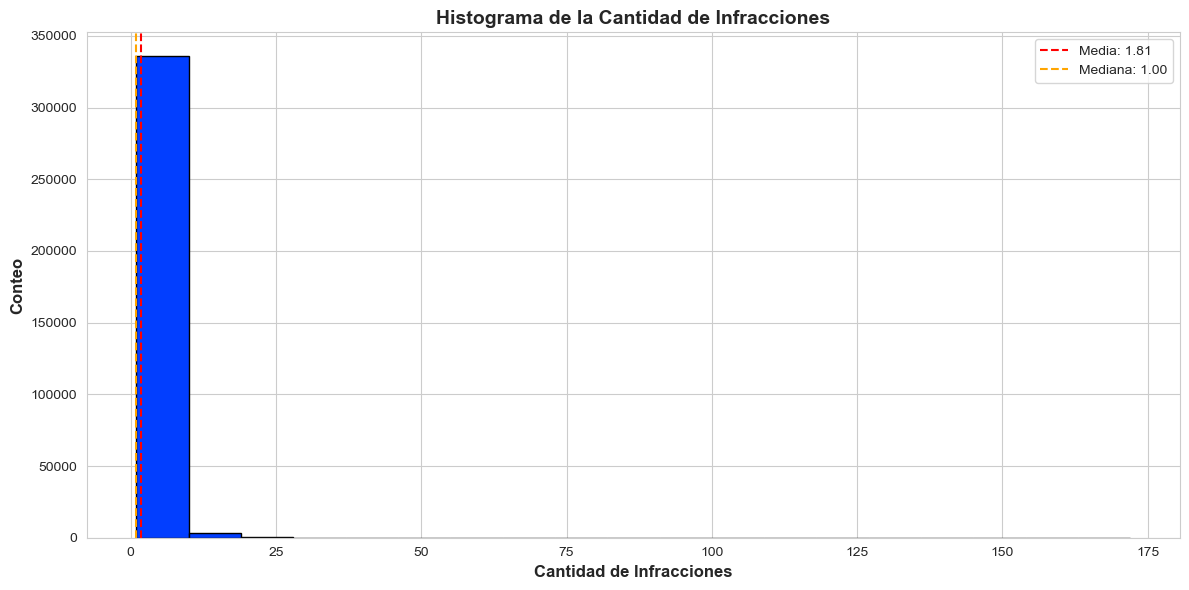

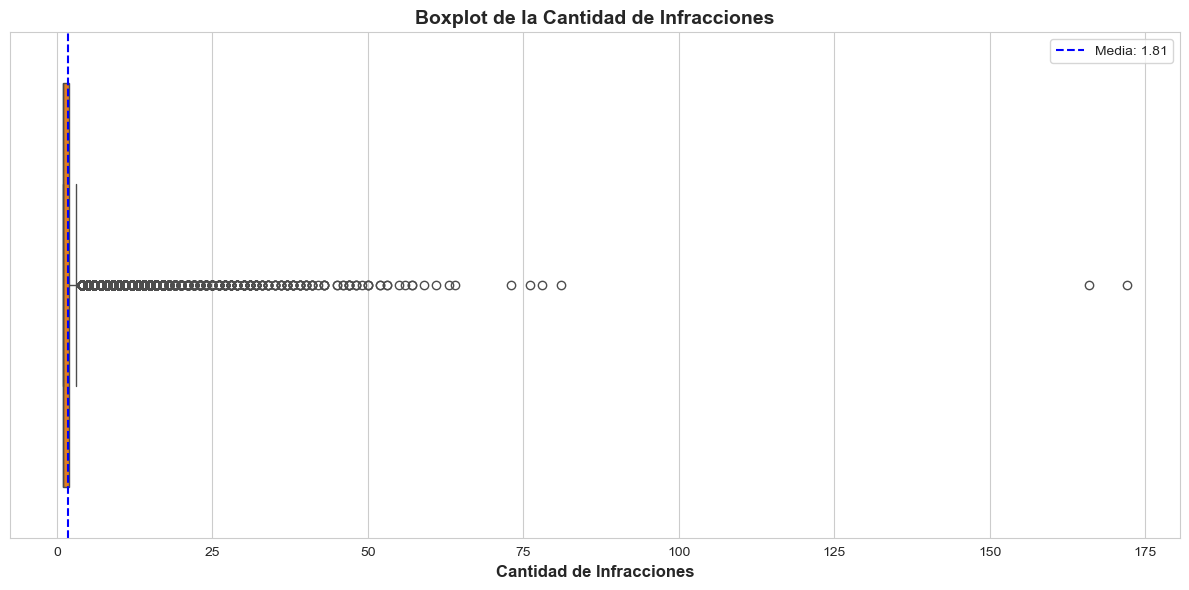

In [923]:
sns.set_style("whitegrid")
colors = sns.color_palette("bright")

skew = round(df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].skew(), 4)
kurtosis = round(df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].kurtosis(), 4)
coef_variacion = (df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].std() / df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].mean()) * 100
media = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].mean()
mediana = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].median()

n = len(df_comparendos_electronicos['CANTIDAD_INFRACCIONES'])
bins_sturges = int(np.log2(n) + 1)
print(f"Bins utilizados (Sturges): {bins_sturges}")

print(f"Skew: {skew}")
print(f"Kurtosis: {kurtosis}")
print(f"Coeficiente de Variación: {round(coef_variacion, 4)} %")

plt.figure(figsize=(12, 6))
counts, bins, patches = plt.hist(df_comparendos_electronicos['CANTIDAD_INFRACCIONES'], edgecolor="black", color=colors[0], bins=bins_sturges)
plt.axvline(media, color='red', linestyle='--', linewidth=1.5, label=f'Media: {media:.2f}')
plt.axvline(mediana, color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: {mediana:.2f}')
plt.title('Histograma de la Cantidad de Infracciones', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Infracciones', fontsize=12, fontweight='bold')
plt.ylabel('Conteo', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.boxplot(x=df_comparendos_electronicos['CANTIDAD_INFRACCIONES'], color=colors[1])
plt.axvline(media, color='blue', linestyle='--', linewidth=1.5, label=f'Media: {media:.2f}')
plt.title('Boxplot de la Cantidad de Infracciones', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Infracciones', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

Los resultados obtenidos revelan características muy particulares en la distribución de la variable `CANTIDAD_INFRACCIONES`:

- **Asimetría (Skewness = 9.6278)**
La asimetría positiva extremadamente alta (mucho mayor que 0) indica que la distribución presenta una **cola extremadamente larga hacia la derecha**. Esto significa que la gran mayoría de los registros se concentran en valores bajos (principalmente 1 y 2), mientras que existen pocos registros con valores muy altos (hasta 172) que extienden significativamente la cola derecha de la distribución. Este comportamiento es consistente con la función de la variable como factor de agrupación, donde la mayoría de las filas representan casos individuales o con baja consolidación.

- **Curtosis (Kurtosis = 348.0843)**
La curtosis extremadamente alta (muy superior a 3, que sería el valor de una distribución normal) indica una **distribución leptocúrtica con colas muy pesadas y un pico muy pronunciado**. Esto confirma que la distribución tiene una concentración inusualmente alta de valores alrededor de la moda (valor 1), junto con la presencia de valores atípicos extremos en la cola derecha que generan esta curtosis tan elevada. Este patrón es típico de variables que funcionan como factores de agregación con dominancia de casos no agrupados.

- **Coeficiente de Variación = 113.9932%**
Un coeficiente de variación superior al 100% indica una **dispersión muy alta en relación con la media**. La desviación estándar (2) es mayor que la media (2), lo que refleja la alta variabilidad relativa de los datos. Este resultado es coherente con la presencia de valores extremos que incrementan considerablemente la dispersión, a pesar de que la mayoría de los registros se concentran en valores bajos.

### Detección de valores atípicos mediante el método del rango intercuartil (IQR)

Se identifican los valores atípicos (outliers) en la variable `CANTIDAD_INFRACCIONES` utilizando el método del rango intercuartil (IQR). Para ello, se calculan el primer cuartil (Q1), el tercer cuartil (Q3) y el rango intercuartil (IQR = Q3 - Q1). Se establecen como límites inferior y superior aquellos valores que se encuentran a 1.5 veces el IQR por debajo de Q1 o por encima de Q3. Los registros que superan estos límites son considerados outliers. Cabe aclarar que estos valores atípicos no serán eliminados, ya que corresponden a agrupaciones válidas de múltiples infracciones con características idénticas y su presencia es inherente a la estructura de la base de datos. El objetivo de esta detección es exclusivamente cuantificarlos y comprender su impacto en la distribución de la variable.

In [924]:
Q1 = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].quantile(0.25)
Q3 = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df_comparendos_electronicos[(df_comparendos_electronicos['CANTIDAD_INFRACCIONES'] < limite_inferior) | 
                                        (df_comparendos_electronicos['CANTIDAD_INFRACCIONES'] > limite_superior)]

print(f"Límite inferior: {limite_inferior.round(0).astype(int)}")
print(f"Límite superior: {limite_superior.round(0).astype(int)}")
print(f"Número de outliers: {len(outliers)}")
print(f"Porcentaje de outliers: {(len(outliers) / len(df_comparendos_electronicos) * 100):.5}%")

Límite inferior: 0
Límite superior: 4
Número de outliers: 33023
Porcentaje de outliers: 9.7236%


Dado que la variable `CANTIDAD_INFRACCIONES` solo toma valores enteros positivos (mínimo 1), el límite inferior negativo no tiene relevancia práctica, ya que ningún valor válido puede estar por debajo de 1.

1. **Definición de outlier en este contexto**:
   - Según el método IQR, cualquier registro con 4 o más infracciones agrupadas es considerado un valor atípico.
   - Sin embargo, como se aclaró previamente, estos valores no representan errores ni inconsistencias, sino agrupaciones válidas de múltiples infracciones con características idénticas.

2. **Proporción significativa de valores "atípicos"**:
   - Con un 9.7% de registros en esta categoría, no se trata de casos aislados o excepcionales, sino de una porción considerable de la base de datos.
   - Esto confirma que la consolidación de múltiples infracciones en un solo registro es un fenómeno recurrente, especialmente en valores de 4 a 24 infracciones.

3. **Distribución de los outliers**:
   - Los valores extremos (por ejemplo, 166 y 172) están incluidos dentro de este grupo, pero representan una fracción mínima del total de outliers.

El 9.7% de los registros clasificados como outliers por el método IQR no deben ser tratados como valores problemáticos, sino como una característica estructural de la base de datos que refleja la consolidación de múltiples infracciones.

### Análisis de comparendos electrónicos por tipo de cámara

Se examina la distribución de los comparendos electrónicos según el tipo de cámara utilizada para la detección de infracciones. Para ello, se agrupan los registros por la variable `Tipo Camara`, sumando la columna `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada categoría. Se calculan los porcentajes de participación y se presentan los resultados mediante una tabla de frecuencias, un gráfico de barras y un gráfico circular que muestran las cantidades absolutas y la proporción relativa de cada tipo de cámara. Esta visualización permite identificar qué tecnologías de vigilancia contribuyen en mayor medida al total de comparendos electrónicos.

Distribución de Comparendos Electrónicos por Tipo de Cámara


,Tipo de Cámara,Comparendos,Porcentaje
0,Fijo,407659,66.35
1,Movil,204973,33.36
2,Carril Bus,1730,0.28


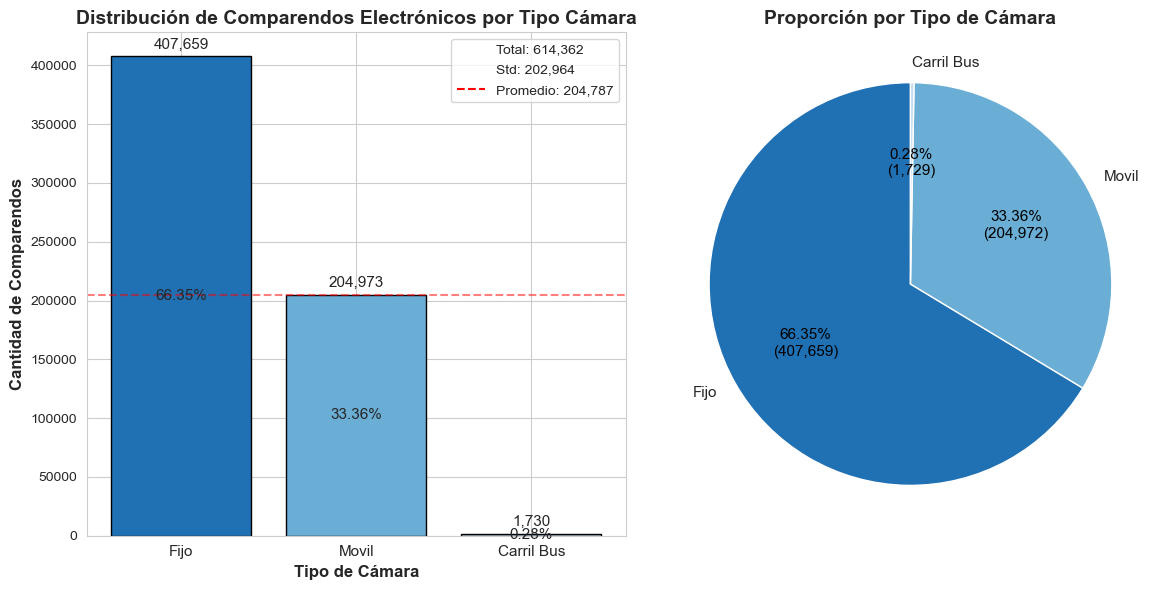

In [925]:
comparendos_por_camara = df_comparendos_electronicos.groupby('Tipo Camara')['CANTIDAD_INFRACCIONES'].sum().sort_values(ascending=False)
total_infracciones = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].sum()
porcentajes = (comparendos_por_camara / total_infracciones * 100).round(2)

desviacion_estandar = comparendos_por_camara.std()

df_grafico = pd.DataFrame({
    'Tipo de Cámara': comparendos_por_camara.index,
    'Comparendos': comparendos_por_camara.values,
    'Porcentaje': porcentajes.values
})

print("Distribución de Comparendos Electrónicos por Tipo de Cámara")
display(df_grafico)

display(HTML("<hr style='border: 1px solid #d3d3d3; margin: 20px 0;'>"))

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.set_style("whitegrid")


colors = sns.color_palette("Blues", n_colors=len(df_grafico))
colors = colors[::-1] 

bars = axes[0].bar(range(len(df_grafico)), df_grafico['Comparendos'], color=colors, edgecolor='black', linewidth=1)
axes[0].set_title('Distribución de Comparendos Electrónicos por Tipo Cámara', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Tipo de Cámara', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(df_grafico)))
axes[0].set_xticklabels(df_grafico['Tipo de Cámara'], fontsize=11)

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, df_grafico['Comparendos'], df_grafico['Porcentaje'])):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(df_grafico['Comparendos'])*0.01),
                 f'{int(conteo):,}', ha='center', va='bottom', fontsize=11)
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
                 f'{porcentaje}%', ha='center', va='center', fontsize=11)

axes[0].axhline(y=total_infracciones/len(df_grafico), color='red', linestyle='--', alpha=0.5)
axes[0].legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_infracciones):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_estandar):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(total_infracciones/len(df_grafico)):,}')
])

wedges, texts, autotexts = axes[1].pie(df_grafico['Comparendos'], 
                                        labels=df_grafico['Tipo de Cámara'],
                                        autopct=lambda pct: f'{pct:.2f}%\n({int(pct/100*total_infracciones):,})',
                                        startangle=90,
                                        colors=colors,
                                        textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_color('black')

axes[1].set_title('Proporción por Tipo de Cámara', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Análisis por categoría:**

1. **Cámaras Fijas (66.35%)**:
   - Constituyen la categoría predominante, concentrando la mayoría del total de infracciones (407,659 eventos).
   - Este tipo de cámara representa la principal fuente de detección de infracciones en la ciudad.

2. **Cámaras Móviles (33.36%)**:
   - Representan aproximadamente un tercio del total de infracciones (204,973 eventos).
   - Aunque su participación es menor que la de las cámaras fijas, sigue siendo una proporción significativa en el control de infracciones.

3. **Cámaras Carril Bus (0.28%)**:
   - Concentran la menor proporción, con solo 1,730 infracciones.
   - Este bajo porcentaje se explica por su implementación reciente, a partir del **17 de octubre de 2025**, lo que limita su período de operación dentro del rango de fechas de la base de datos.
   - A pesar de su baja participación actual, se espera que su contribución aumente en períodos posteriores a medida que el sistema de cámaras Carril Bus continúe operando.

---

**Comparación con el promedio:**

- **Cámaras Fijas**: Superan ampliamente el promedio (407,659 vs 204,787), casi el doble.
- **Cámaras Móviles**: Se aproximan al promedio (204,973 vs 204,787), prácticamente iguales.
- **Cámaras Carril Bus**: Se encuentran muy por debajo del promedio (1,730 vs 204,787), debido a su reciente implementación.

La alta concentración en cámaras fijas sugiere que cualquier mejora o mantenimiento de esta infraestructura tendría un impacto significativo en la detección de infracciones.

### Análisis de comparendos electrónicos por código de infracción

Se examina la distribución de los comparendos electrónicos según el código de infracción, utilizando la suma ponderada de `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada categoría. Se calculan los porcentajes de participación y se presentan los resultados mediante una tabla de frecuencias, acompañada de las descripciones correspondientes a cada código obtenidas de la fuente oficial. Complementariamente, se visualiza la distribución a través de un gráfico de barras que muestra las cantidades absolutas y los porcentajes, permitiendo identificar qué tipos de infracción son más frecuentes en el sistema de comparendos electrónicos.

Distribución de Comparendos Electrónicos por Código de Infracción


,Código de Infracción,Comparendos,Porcentaje
0,C29,284755,46.35
1,C02,204975,33.36
2,C03,65230,10.62
3,D04,54303,8.84
4,C32,3369,0.55
5,C14,1730,0.28



Descripción de los códigos de infracción


,COD_INFRACCION,DESC_INFRACCION
0,C29,"Conducir un vehículo a velocidad superior a la máxima permitida, la cual deberá estar señalizada en forma sectorizada, la cual no podrá ser superior"
1,C02,Estacionar un vehículo en los sitios prohibidos
2,C03,"Bloquear una calzada o intersección con un vehículo, salvo cuando el bloqueo obedezca a la ocurrencia de un accidente"
3,D04,"No detenerse ante luz roja o amarilla de semáforo,una señal de PARE,un semáforo intermitente en rojo. En el caso de motocicletas se procederá a la inmovilización hasta tanto no pague el valor de la multa o a la autoridad competente decida sobre si imposición en los términos de los art 135,136 CNT"
4,C32,No respetar el paso de peatones que cruzan una vía en sitio permitido para ellos o no darles la prelación en las franjas para ello establecidas
5,C14,Transitar por sitios restringidos o en horas prohibidas por la autoridad competente


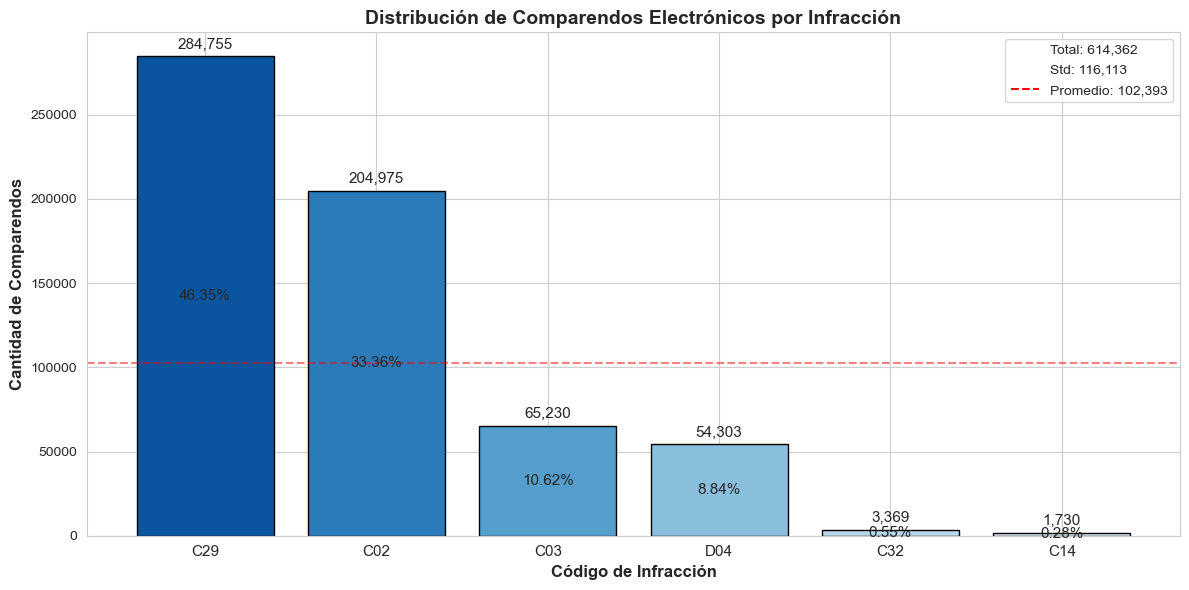

In [926]:
comparendos_por_infraccion = df_comparendos_electronicos.groupby('COD_INFRACCION')['CANTIDAD_INFRACCIONES'].sum().sort_values(ascending=False)
total_infracciones = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].sum()
porcentajes = (comparendos_por_infraccion / total_infracciones * 100).round(2)

desviacion_estandar = comparendos_por_infraccion.std()

df_grafico = pd.DataFrame({
    'Código de Infracción': comparendos_por_infraccion.index,
    'Comparendos': comparendos_por_infraccion.values,
    'Porcentaje': porcentajes.values
})

print("Distribución de Comparendos Electrónicos por Código de Infracción")
display(df_grafico)


descripciones = df_comparendos_electronicos.groupby('COD_INFRACCION')['DESC_INFRACCION'].first().reset_index()
descripciones = descripciones.set_index('COD_INFRACCION').loc[df_grafico['Código de Infracción']].reset_index()
print("\nDescripción de los códigos de infracción")

pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(descripciones)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

display(HTML("<hr style='border: 1px solid #d3d3d3; margin: 20px 0;'>"))

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

colors = sns.color_palette("Blues", n_colors=len(df_grafico))
colors = colors[::-1]  

bars = plt.bar(range(len(df_grafico)), df_grafico['Comparendos'], color=colors, edgecolor='black', linewidth=1)

plt.title('Distribución de Comparendos Electrónicos por Infracción', fontsize=14, fontweight='bold')
plt.xlabel('Código de Infracción', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
plt.xticks(range(len(df_grafico)), df_grafico['Código de Infracción'], fontsize=11)

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, df_grafico['Comparendos'], df_grafico['Porcentaje'])):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(df_grafico['Comparendos'])*0.01),
             f'{int(conteo):,}', ha='center', va='bottom', fontsize=11)
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
             f'{porcentaje}%', ha='center', va='center', fontsize=11)

plt.axhline(y=total_infracciones/len(df_grafico), color='red', linestyle='--', alpha=0.5)

plt.legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_infracciones):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_estandar):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(total_infracciones/len(df_grafico)):,}')
])

plt.tight_layout()
plt.show()

**Análisis por categoría:**

1. **C29 - Exceso de velocidad (46.35%)**:
   - Es la infracción más frecuente, concentrando casi la mitad del total de comparendos electrónicos (284,755 eventos).
   - Este resultado evidencia que el exceso de velocidad es la principal causa de detección por parte de las cámaras de vigilancia.

2. **C02 - Estacionar en sitios prohibidos (33.36%)**:
   - Representa un tercio del total de infracciones (204,975 eventos), siendo la segunda causa más común.
   - La alta incidencia de esta infracción sugiere una problemática significativa en cuanto al cumplimiento de las normas de estacionamiento.

3. **C03 - Bloquear calzada o intersección (10.62%)**:
   - Acumula el 10.62% de los comparendos (65,230 eventos), consolidándose como la tercera infracción más frecuente.

4. **D04 - No detenerse ante un semáforo o una señal de «pare» (8.84%)**:
   - Representa el 8.84% de los comparendos (54,303 eventos), evidenciando una problemática importante en el respeto de las señales de tránsito.

5. **C32 - No respetar paso de peatones (0.55%)**:
   - Con 3,369 eventos, su participación es baja en comparación con las infracciones anteriores.

6. **C14 - Transitar por sitios restringidos (0.28%)**:
   - Es la infracción con menor participación (1,730 eventos), lo cual es coherente con su reciente implementación a través de las cámaras Carril Bus a partir del 17 de octubre de 2025.

---

**Comparación con el promedio:**

- **C29 (284,755)**: Supera ampliamente el promedio.
- **C02 (204,975)**: Duplica el promedio.
- **C03 (65,230)**: Se encuentra por debajo del promedio.
- **D04 (54,303)**: También por debajo del promedio.
- **C32 (3,369)**: Muy por debajo del promedio.
- **C14 (1,730)**: Extremadamente por debajo del promedio.


Las campañas de control y educación vial deberían enfocarse prioritariamente en el exceso de velocidad y el estacionamiento indebido.

### Análisis de comparendos electrónicos por servicio del vehículo infractor

Se examina la distribución de los comparendos electrónicos según el servicio del vehículo infractor, utilizando la suma ponderada de `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada categoría. Se calculan los porcentajes de participación y se presentan los resultados mediante una tabla de frecuencias, un gráfico de barras que muestra las cantidades absolutas con sus respectivos porcentajes, y un gráfico circular que ilustra la proporción relativa de cada categoría. Para mejorar la visualización, las categorías con menos de 1,000 infracciones se agrupan en una categoría "OTROS". Este análisis permite identificar qué tipo de servicio vehicular está más involucrado en las infracciones detectadas por el sistema de cámaras.

Distribución de Comparendos Electrónicos por Servicio de Vehículo


,Servicio del Vehículo,Comparendos,Porcentaje
0,PARTICULAR,525987,85.62
1,PUBLICO,87554,14.25
2,OFICIAL,819,0.13
3,DIPLOMATICO,2,0.00


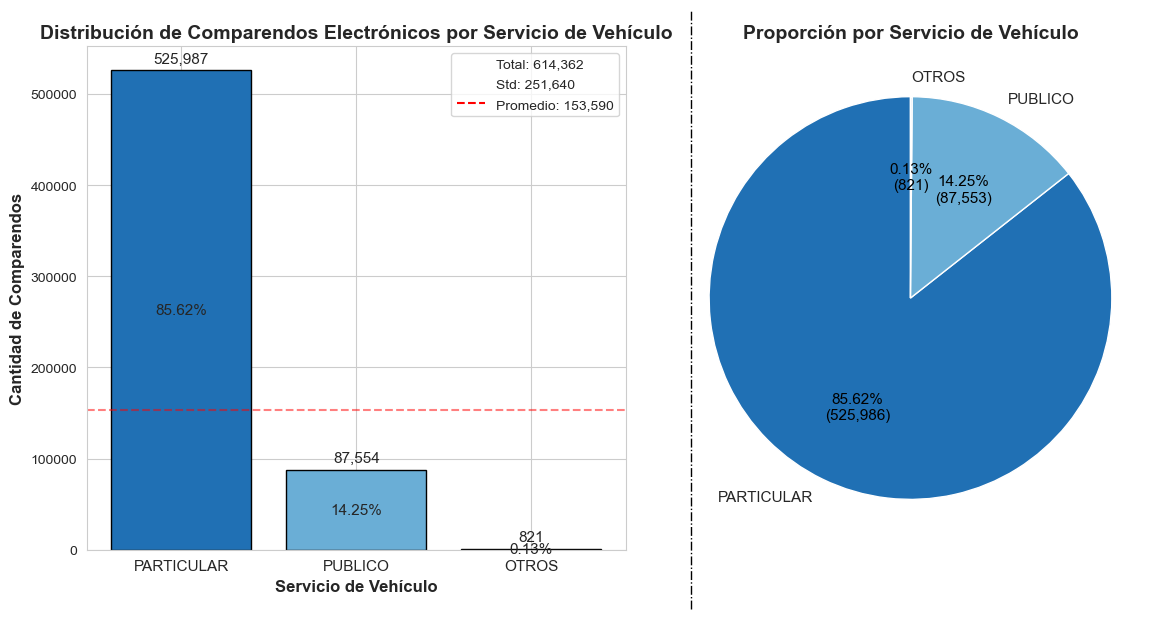

In [927]:
comparendos_por_servicio = df_comparendos_electronicos.groupby('SERVICIO_VEHICULO_INFRACTOR')['CANTIDAD_INFRACCIONES'].sum().sort_values(ascending=False)
total_infracciones = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].sum()
porcentajes = (comparendos_por_servicio / total_infracciones * 100).round(2)

desviacion_estandar = comparendos_por_servicio.std()

df_original = pd.DataFrame({
    'Servicio del Vehículo': comparendos_por_servicio.index,
    'Comparendos': comparendos_por_servicio.values,
    'Porcentaje': porcentajes.values
})

print("Distribución de Comparendos Electrónicos por Servicio de Vehículo")
display(df_original)

display(HTML("<hr style='border: 1px solid #d3d3d3; margin: 20px 0;'>"))

servicios_otros = ['OFICIAL', 'DIPLOMATICO']

nuevas_categorias = [
    {'Servicio del Vehículo': 'PARTICULAR', 'Comparendos': df_original[df_original['Servicio del Vehículo'] == 'PARTICULAR']['Comparendos'].sum()},
    {'Servicio del Vehículo': 'PUBLICO', 'Comparendos': df_original[df_original['Servicio del Vehículo'] == 'PUBLICO']['Comparendos'].sum()},
    {'Servicio del Vehículo': 'OTROS', 'Comparendos': df_original[df_original['Servicio del Vehículo'].isin(servicios_otros)]['Comparendos'].sum()}
]

df_agrupado = pd.DataFrame(nuevas_categorias)
df_agrupado = df_agrupado.sort_values('Comparendos', ascending=False).reset_index(drop=True)
df_agrupado['Porcentaje'] = (df_agrupado['Comparendos'] / total_infracciones * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.set_style("whitegrid")

colors = sns.color_palette("Blues", n_colors=len(df_agrupado))
colors = colors[::-1]  

bars = axes[0].bar(range(len(df_agrupado)), df_agrupado['Comparendos'], color=colors, edgecolor='black', linewidth=1)
axes[0].set_title('Distribución de Comparendos Electrónicos por Servicio de Vehículo', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Servicio de Vehículo', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(df_agrupado)))
axes[0].set_xticklabels(df_agrupado['Servicio del Vehículo'], fontsize=11)

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, df_agrupado['Comparendos'], df_agrupado['Porcentaje'])):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(df_agrupado['Comparendos'])*0.01),
                 f'{int(conteo):,}', ha='center', va='bottom', fontsize=11)
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
                 f'{porcentaje}%', ha='center', va='center', fontsize=11)

axes[0].axhline(y=total_infracciones/len(comparendos_por_servicio), color='red', linestyle='--', alpha=0.5)

axes[0].legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_infracciones):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_estandar):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(total_infracciones/len(comparendos_por_servicio)):,}')
])


fig.add_artist(plt.Line2D([0.58, 0.58], [0, 1], transform=fig.transFigure, color='black', linewidth=1, linestyle='dashdot', alpha=1))

wedges, texts, autotexts = axes[1].pie(df_agrupado['Comparendos'], 
                                        labels=df_agrupado['Servicio del Vehículo'],
                                        autopct=lambda pct: f'{pct:.2f}%\n({int(pct/100*total_infracciones):,})',
                                        startangle=90,
                                        colors=colors,
                                        textprops={'fontsize': 11})
for autotext in autotexts:
    autotext.set_color('black')

axes[1].set_title('Proporción por Servicio de Vehículo', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

**Análisis por categoría:**

1. **Vehículos particulares (85.62%)**:
   - Constituyen la categoría predominante, concentrando la mayoría del total de infracciones (525,987 eventos).
   - Este resultado evidencia que los conductores de vehículos particulares son los principales infractores detectados por el sistema de cámaras.

2. **Vehículos de servicio público (14.25%)**:
   - Representan aproximadamente una séptima parte del total de infracciones (87,554 eventos).
   - Aunque su participación es significativamente menor que la de los particulares, sigue siendo una proporción relevante que merece atención.

3. **Vehículos oficiales (0.13%)**:
   - Con solo 819 infracciones, su participación es marginal en el total de comparendos.

4. **Vehículos diplomáticos (0.00%)**:
   - Con apenas 2 infracciones, su presencia es prácticamente nula, lo cual puede deberse a un bajo parque automotor de esta categoría en circulación.

---

**Comparación con el promedio:**

- **Vehículos particulares (525,987)**: Superan ampliamente el promedio.
- **Vehículos de servicio público (87,554)**: Se encuentran por debajo del promedio.
- **Vehículos oficiales (819)**: Muy por debajo del promedio.
- **Vehículos diplomáticos (2)**: Extremadamente por debajo del promedio.

Las campañas de educación y control deberían estar dirigidas prioritariamente a conductores de vehículos particulares, dado que constituyen el grupo con mayor incidencia de infracciones. Además, aunque los vehículos de servicio público tienen menor participación, su impacto en la seguridad vial y la percepción ciudadana podría ameritar acciones específicas.


### Análisis de comparendos electrónicos por clase de vehículo infractor

Se examina la distribución de los comparendos electrónicos según la clase del vehículo infractor, utilizando la suma ponderada de `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada categoría. Se calculan los porcentajes de participación y se presentan los resultados mediante una tabla de frecuencias y un gráfico de barras que muestra las 10 clases de vehículo con mayor número de comparendos. Debido a que algunas categorías presentan nombres extensos que dificultan su visualización en el gráfico, se opta por representarlas mediante índices numéricos, manteniendo la legibilidad de la información sin comprometer la presentación de los datos. Este análisis permite identificar qué tipos de vehículos están más involucrados en las infracciones detectadas por el sistema de cámaras.

Distribución de Comparendos Electrónicos por Clase de Vehículo


,0,1,2,3,4,5,6,7,8,9,10,11,12,13
Clase del Vehículo,AUTOMOVIL,CAMIONETA,MOTOCICLETA,CAMPERO,CAMION,BUS,MICROBUS,BUSETA,VOLQUETA,TRACTOCAMION,MOTOCARRO,CUATRIMOTO,NO REPORTADO,SIN CLASE
Comparendos,321955,129827,102708,39955,9117,5585,2248,1501,706,579,168,7,5,1
Porcentaje,52.4,21.13,16.72,6.5,1.48,0.91,0.37,0.24,0.11,0.09,0.03,0.0,0.0,0.0


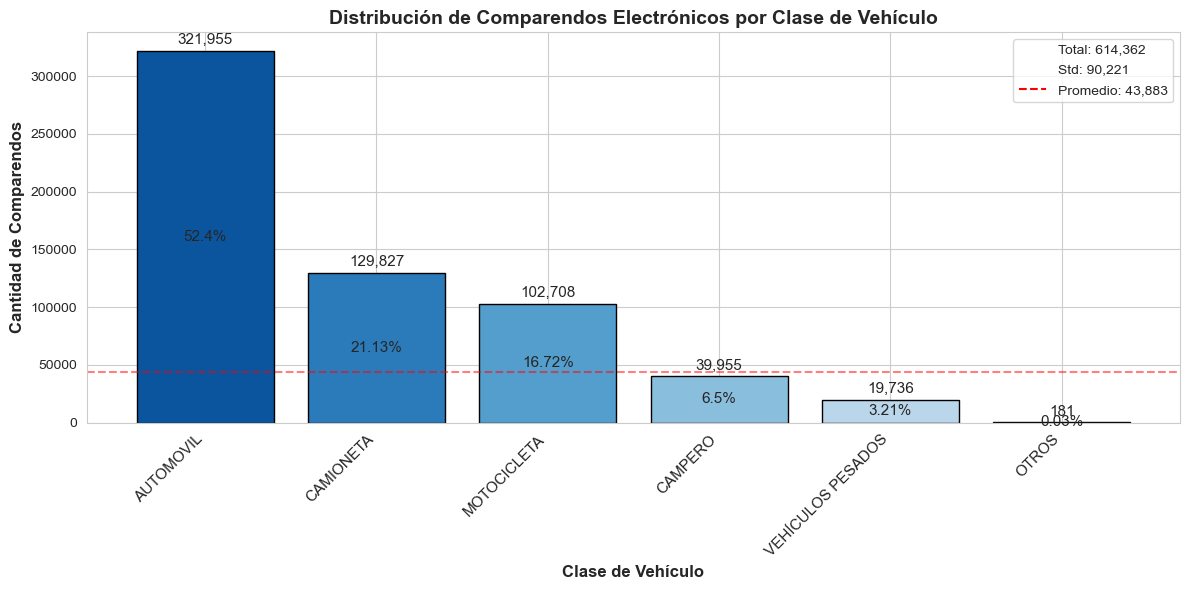

In [928]:
comparendos_por_clase = df_comparendos_electronicos.groupby('CLASE_VEHICULO_INFRACTOR')['CANTIDAD_INFRACCIONES'].sum().sort_values(ascending=False)
total_infracciones = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].sum()
porcentajes = (comparendos_por_clase / total_infracciones * 100).round(2)

desviacion_estandar = comparendos_por_clase.std()

df_original = pd.DataFrame({
    'Clase del Vehículo': comparendos_por_clase.index,
    'Comparendos': comparendos_por_clase.values,
    'Porcentaje': porcentajes.values
})

print("Distribución de Comparendos Electrónicos por Clase de Vehículo")
display(df_original.T)

display(HTML("<hr style='border: 1px solid #d3d3d3; margin: 20px 0;'>"))

vehiculos_pesados = ['CAMION', 'BUS', 'MICROBUS', 'BUSETA', 'VOLQUETA', 'TRACTOCAMION']
otros = ['MOTOCARRO', 'CUATRIMOTO', 'NO REPORTADO', 'SIN CLASE']

nuevas_categorias = [
    {'Clase del Vehículo': 'AUTOMOVIL', 'Comparendos': df_original[df_original['Clase del Vehículo'] == 'AUTOMOVIL']['Comparendos'].sum()},
    {'Clase del Vehículo': 'CAMIONETA', 'Comparendos': df_original[df_original['Clase del Vehículo'] == 'CAMIONETA']['Comparendos'].sum()},
    {'Clase del Vehículo': 'MOTOCICLETA', 'Comparendos': df_original[df_original['Clase del Vehículo'] == 'MOTOCICLETA']['Comparendos'].sum()},
    {'Clase del Vehículo': 'CAMPERO', 'Comparendos': df_original[df_original['Clase del Vehículo'] == 'CAMPERO']['Comparendos'].sum()},
    {'Clase del Vehículo': 'VEHÍCULOS PESADOS', 'Comparendos': df_original[df_original['Clase del Vehículo'].isin(vehiculos_pesados)]['Comparendos'].sum()},
    {'Clase del Vehículo': 'OTROS', 'Comparendos': df_original[df_original['Clase del Vehículo'].isin(otros)]['Comparendos'].sum()}
]

df_agrupado = pd.DataFrame(nuevas_categorias)
df_agrupado = df_agrupado.sort_values('Comparendos', ascending=False).reset_index(drop=True)
df_agrupado['Porcentaje'] = (df_agrupado['Comparendos'] / total_infracciones * 100).round(2)

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

colors = sns.color_palette("Blues", n_colors=len(df_agrupado))
colors = colors[::-1]  

bars = plt.bar(range(len(df_agrupado)), df_agrupado['Comparendos'], color=colors, edgecolor='black', linewidth=1)

plt.title('Distribución de Comparendos Electrónicos por Clase de Vehículo', fontsize=14, fontweight='bold')
plt.xlabel('Clase de Vehículo', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
plt.xticks(range(len(df_agrupado)), df_agrupado['Clase del Vehículo'], fontsize=11, rotation=45, ha='right')

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, df_agrupado['Comparendos'], df_agrupado['Porcentaje'])):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(df_agrupado['Comparendos'])*0.01),
             f'{int(conteo):,}', ha='center', va='bottom', fontsize=11)
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
             f'{porcentaje}%', ha='center', va='center', fontsize=11)

plt.axhline(y=total_infracciones/len(comparendos_por_clase), color='red', linestyle='--', alpha=0.5)

plt.legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_infracciones):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_estandar):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(total_infracciones/len(comparendos_por_clase)):,}')
])

plt.tight_layout()
plt.show()

**Análisis por categorías principales:**

1. **Automóvil (52.40%)**:
   - Es la clase de vehículo con mayor participación, concentrando la mayoría del total de infracciones (321,955 eventos).

2. **Camioneta (21.13%)**:
   - Constituye la segunda clase más infractora, con 129,827 infracciones, representando más de una quinta parte del total.

3. **Motocicleta (16.72%)**:
   - Ocupa el tercer lugar con 102,708 infracciones, equivalente a aproximadamente una sexta parte del total.
   - A pesar de no ser la categoría predominante, su participación es significativa y merece atención por las implicaciones en seguridad vial.

4. **Campero (6.50%)**:
   - Con 39,955 infracciones, es la cuarta categoría en importancia, aunque con una participación mucho menor que las tres primeras.

5. **Vehículos de carga y transporte público (1.48% - 0.09%)**:
   - Las categorías como camión, bus, microbús, buseta, volqueta y tractocamión presentan porcentajes bajos, sumando en conjunto aproximadamente el 3.2% del total.

6. **Categorías marginales**:
   - Motocarro, cuatrimoto, "no reportado" y "sin clase" tienen participaciones inferiores al 0.03%, sumando menos de 200 infracciones en total.

---

**Concentración en tres clases principales:**

- **Automóvil**: 52.40%
- **Camioneta**: 21.13%
- **Motocicleta**: 16.72%
- **Total acumulado**: 90.25%

Este patrón refleja que los vehículos livianos de uso particular o particular-comercial son los principales protagonistas de las infracciones detectadas por el sistema de cámaras.

---

**Comparación con el promedio:**

- **Automóvil (321,955)**: Supera ampliamente el promedio.
- **Camioneta (129,827)**: Triplica el promedio.
- **Motocicleta (102,708)**: Más del doble del promedio.
- **Campero (39,955)**: Se aproxima al promedio.
- **Demás categorías**: Se encuentran por debajo del promedio, con participaciones decrecientes.

Las estrategias de prevención y control deben priorizar los vehículos livianos, especialmente automóviles y camionetas. Además, aunque las motocicletas tienen menor participación que automóviles y camionetas, su importancia en seguridad vial justifica acciones específicas.

### Análisis de comparendos electrónicos por cámara y dirección

Se examina la distribución de los comparendos electrónicos según la ubicación específica de la cámara y la dirección de detección, utilizando la suma ponderada de `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada punto de control. Se presentan los resultados mediante una tabla de frecuencias que muestra todas las ubicaciones con sus respectivos conteos y porcentajes, y un gráfico de barras que destaca las 10 cámaras con mayor número de comparendos. Debido a que los nombres de las ubicaciones contienen descripciones extensas de calles y direcciones que dificultan su visualización directa en el gráfico, se opta por representarlas mediante índices numéricos, manteniendo la legibilidad de la información sin comprometer la presentación de los datos. Este análisis permite identificar los puntos críticos de detección de infracciones en la ciudad.

Distribución de Comparendos Electrónicos por Cámara y Dirección


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55
Cámara y Dirección,Carro mal parqueo Sur,Carro mal parqueo Norte,VIA 11 CON CARRERA 8,Carro mal parqueo Sur - Norte,CARRERA 51B CON CALLE 79,CALLE 30 CON CARRERA 6B,CALLE 45 CON CARRERA 1,CALLE 30 CON CARRERA 8,CARRERA 53 CON CALLE 104,CALLE 82 CON CARRERA 51B,CARRERA 51B CON CALLE 103,Carro mal parqueo alto norte,CARRERA 6 CON CALLE 72,AVENIDA CIRCUNVALAR CON CARRERA 9G,VIA 40 CON CALLE 73,CALLE 45 CON CARRERA 20,CALLE 82 CON CARRERA 56,Carro mal parqueo alto sur,CALLE 45 CON CARRERA 21,CARRERA 15 CON CALLE 21,CALLE 45B CARRERA 14,CALLE 72 CON CARRERA 44,CALLE 84 CON CARRERA 59,CALLE 94 CON CARRERA 58,CARRERA 46 CON CALLE 100,CALLE 56 CON CARRERA 14,CALLE 19 CON CARRERA 4C,CALLE 87 CON CARRERA 21,CALLE 76 CON CARRERA 38C-100,CALLE 19 CON CARRERA 3D,CALLE 53 CON CARRERA 45,CARRERA 53 CON CALLE 86,CALLE 70 CON CARRERA 46,CALLE 34 CON CARRERA 45,CARRERA 53 ENTRE CALLE 104 Y 106,AVENIDA CIRCUNVALAR CON CARRERA 31,CALLE 98 CON CARRERA 56,CALLE 45 CON CARRERA 21 SENTIDO SUR-NORTE,CALLE 61 CON CARRERA 35,CALLE 45 CON CARRERA 21 SENTIDO NORTE-SUR,CALLE 45B CON CARRERA 14,CARRERA 45 CON CALLE 53,CARRERA 46 CON CALLE 34 SENTIDO SUR-NORTE,CALLE 70 CON CARRERA 46 SENTIDO SUR-NORTE,CALLE 84 ENTRE CARRERA 59 Y 59B,CARRERA 27 CON CALLE 82C,CALLE 70 CON CARRERA 46 SENTIDO NORTE-SUR,AVENIDA CIRCUNVALAR (CALLE 110) ENTRE CARRERA 9G Y 12 SENTIDO SUR A NORTE,CALLE 45 CON CARRERA 8 SENTIDO SUR-NORTE,AVENIDA CIRCUNVALAR (CALLE 110) ENTRE CARRERA 9G Y 12 SENTIDO NORTE A SUR,CALLE 45 CON CARRERA 33 SENTIDO NORTE-SUR,CALLE 45 CON CARRERA 43 SENTIDO SUR-NORTE,CALLE 45 CON CARRERA 43 SENTIDO NORTE-SUR,CALLE 45 CON CARRERA 1E SENTIDO SUR-NORTE,CARRERA 46 CON CALLE 34 SENTIDO NORTE-SUR,CALLE 45 CON CARRERA 1E SENTIDO NORTE-SUR
Comparendos,73544,65306,52029,37993,33293,24261,22800,21832,20593,19627,17116,17090,16292,16186,12983,12740,12032,11040,10036,9910,9520,8850,7958,7863,7705,7385,6980,6319,6236,6215,6030,4394,4241,3133,2386,2225,2128,1182,1176,1125,1048,751,725,562,521,390,300,102,69,66,32,18,9,8,4,3
Porcentaje,11.97,10.63,8.47,6.18,5.42,3.95,3.71,3.55,3.35,3.19,2.79,2.78,2.65,2.63,2.11,2.07,1.96,1.8,1.63,1.61,1.55,1.44,1.3,1.28,1.25,1.2,1.14,1.03,1.02,1.01,0.98,0.72,0.69,0.51,0.39,0.36,0.35,0.19,0.19,0.18,0.17,0.12,0.12,0.09,0.08,0.06,0.05,0.02,0.01,0.01,0.01,0.0,0.0,0.0,0.0,0.0


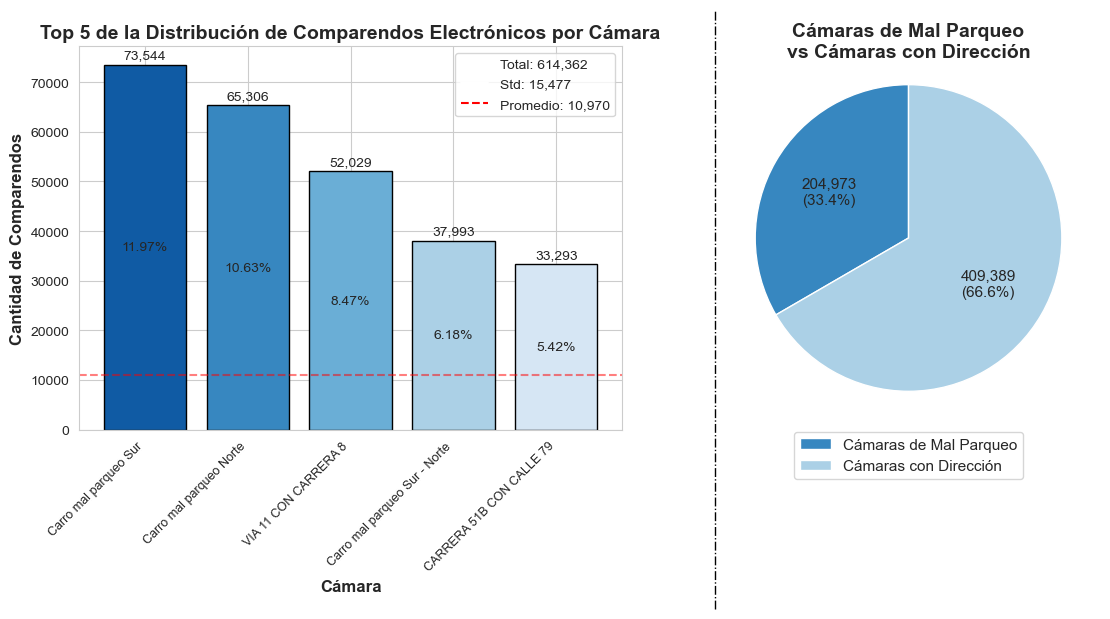

In [929]:
comparendos_por_direccion = df_comparendos_electronicos.groupby('Camara_y_direccion')['CANTIDAD_INFRACCIONES'].sum().sort_values(ascending=False)
total_infracciones = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].sum()
porcentajes = (comparendos_por_direccion / total_infracciones * 100).round(2)

desviacion_estandar = comparendos_por_direccion.std()

df_grafico = pd.DataFrame({
    'Cámara y Dirección': comparendos_por_direccion.index,
    'Comparendos': comparendos_por_direccion.values,
    'Porcentaje': porcentajes.values
})

print("Distribución de Comparendos Electrónicos por Cámara y Dirección")
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(df_grafico.T)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

display(HTML("<hr style='border: 1px solid #d3d3d3; margin: 20px 0;'>"))

top_5 = df_grafico.head(5)

categorias_mal_parqueo = df_grafico[df_grafico['Cámara y Dirección'].str.contains('mal', case=False, na=False)]
categorias_direccion = df_grafico[~df_grafico['Cámara y Dirección'].str.contains('mal', case=False, na=False)]

df_torta = pd.DataFrame({
    'Categoría': ['Cámaras de Mal Parqueo', 'Cámaras con Dirección'],
    'Comparendos': [categorias_mal_parqueo['Comparendos'].sum(), categorias_direccion['Comparendos'].sum()]
})
df_torta['Porcentaje'] = (df_torta['Comparendos'] / total_infracciones * 100).round(2)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
sns.set_style("whitegrid")

colors = sns.color_palette("Blues", n_colors=len(top_5))
colors = colors[::-1]

bars = axes[0].bar(range(len(top_5)), top_5['Comparendos'], color=colors, edgecolor='black', linewidth=1)
axes[0].set_title('Top 5 de la Distribución de Comparendos Electrónicos por Cámara', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cámara', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
axes[0].set_xticks(range(len(top_5)))
axes[0].set_xticklabels(top_5['Cámara y Dirección'], fontsize=9, rotation=45, ha='right')

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, top_5['Comparendos'], top_5['Porcentaje'])):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(top_5['Comparendos'])*0.01),
                 f'{int(conteo):,}', ha='center', va='bottom', fontsize=10)
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
                 f'{porcentaje}%', ha='center', va='center', fontsize=10)

axes[0].axhline(y=total_infracciones/len(df_grafico), color='red', linestyle='--', alpha=0.5)

axes[0].legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_infracciones):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_estandar):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(total_infracciones/len(df_grafico)):,}')
])

colors_torta = sns.color_palette("Blues", n_colors=len(df_torta))
colors_torta = colors_torta[::-1]

fig.add_artist(plt.Line2D([0.6, 0.6], [0, 1], transform=fig.transFigure, color='black', linewidth=1, linestyle='dashdot', alpha=1))

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f'{val:,}\n({pct:.1f}%)'
    return my_autopct

wedges, texts, autotexts = axes[1].pie(df_torta['Comparendos'], 
                                        labels=None,
                                        autopct=make_autopct(df_torta['Comparendos']),
                                        startangle=90,
                                        colors=colors_torta,
                                        textprops={'fontsize': 11})



axes[1].legend(df_torta['Categoría'], loc='lower center', bbox_to_anchor=(0.5, -0.15), ncol=1, fontsize=11)

axes[1].set_title('Cámaras de Mal Parqueo\nvs Cámaras con Dirección', fontsize=14, fontweight='bold', loc='center', y=0.95)

plt.tight_layout()
plt.show()

Distribución de Comparendos Electrónicos por Cámara de Mal Parqueo


,Cámara y Dirección,Comparendos,Porcentaje
0,Carro mal parqueo Sur,73544,11.97
1,Carro mal parqueo Norte,65306,10.63
3,Carro mal parqueo Sur - Norte,37993,6.18
11,Carro mal parqueo alto norte,17090,2.78
17,Carro mal parqueo alto sur,11040,1.80


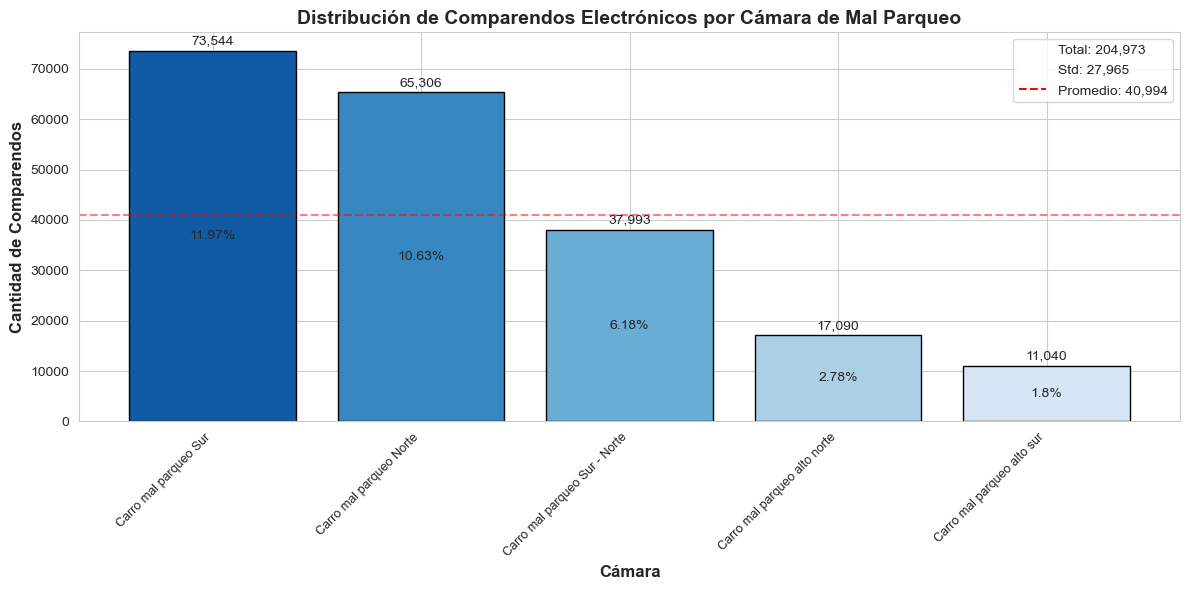

In [930]:
total_mal_parqueo = categorias_mal_parqueo['Comparendos'].sum()
desviacion_mal_parqueo = categorias_mal_parqueo['Comparendos'].std()
promedio_mal_parqueo = categorias_mal_parqueo['Comparendos'].mean()

print("Distribución de Comparendos Electrónicos por Cámara de Mal Parqueo")
display(categorias_mal_parqueo)

display(HTML("<hr style='border: 1px solid #d3d3d3; margin: 20px 0;'>"))

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

colors = sns.color_palette("Blues", n_colors=len(categorias_mal_parqueo))
colors = colors[::-1]

bars = plt.bar(range(len(categorias_mal_parqueo)), categorias_mal_parqueo['Comparendos'], color=colors, edgecolor='black', linewidth=1)

plt.title('Distribución de Comparendos Electrónicos por Cámara de Mal Parqueo', fontsize=14, fontweight='bold')
plt.xlabel('Cámara', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
plt.xticks(range(len(categorias_mal_parqueo)), categorias_mal_parqueo['Cámara y Dirección'], fontsize=9, rotation=45, ha='right')

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, categorias_mal_parqueo['Comparendos'], categorias_mal_parqueo['Porcentaje'])):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(categorias_mal_parqueo['Comparendos'])*0.01),
             f'{int(conteo):,}', ha='center', va='bottom', fontsize=10)
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
             f'{porcentaje}%', ha='center', va='center', fontsize=10)

plt.axhline(y=promedio_mal_parqueo, color='red', linestyle='--', alpha=0.5)

plt.legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_mal_parqueo):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_mal_parqueo):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(promedio_mal_parqueo):,}')
])

plt.tight_layout()
plt.show()

Distribución de Comparendos Electrónicos por Cámara con Dirección


,2,4,5,6,7,8,9,10,12,13,14,15,16,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55
Cámara y Dirección,VIA 11 CON CARRERA 8,CARRERA 51B CON CALLE 79,CALLE 30 CON CARRERA 6B,CALLE 45 CON CARRERA 1,CALLE 30 CON CARRERA 8,CARRERA 53 CON CALLE 104,CALLE 82 CON CARRERA 51B,CARRERA 51B CON CALLE 103,CARRERA 6 CON CALLE 72,AVENIDA CIRCUNVALAR CON CARRERA 9G,VIA 40 CON CALLE 73,CALLE 45 CON CARRERA 20,CALLE 82 CON CARRERA 56,CALLE 45 CON CARRERA 21,CARRERA 15 CON CALLE 21,CALLE 45B CARRERA 14,CALLE 72 CON CARRERA 44,CALLE 84 CON CARRERA 59,CALLE 94 CON CARRERA 58,CARRERA 46 CON CALLE 100,CALLE 56 CON CARRERA 14,CALLE 19 CON CARRERA 4C,CALLE 87 CON CARRERA 21,CALLE 76 CON CARRERA 38C-100,CALLE 19 CON CARRERA 3D,CALLE 53 CON CARRERA 45,CARRERA 53 CON CALLE 86,CALLE 70 CON CARRERA 46,CALLE 34 CON CARRERA 45,CARRERA 53 ENTRE CALLE 104 Y 106,AVENIDA CIRCUNVALAR CON CARRERA 31,CALLE 98 CON CARRERA 56,CALLE 45 CON CARRERA 21 SENTIDO SUR-NORTE,CALLE 61 CON CARRERA 35,CALLE 45 CON CARRERA 21 SENTIDO NORTE-SUR,CALLE 45B CON CARRERA 14,CARRERA 45 CON CALLE 53,CARRERA 46 CON CALLE 34 SENTIDO SUR-NORTE,CALLE 70 CON CARRERA 46 SENTIDO SUR-NORTE,CALLE 84 ENTRE CARRERA 59 Y 59B,CARRERA 27 CON CALLE 82C,CALLE 70 CON CARRERA 46 SENTIDO NORTE-SUR,AVENIDA CIRCUNVALAR (CALLE 110) ENTRE CARRERA 9G Y 12 SENTIDO SUR A NORTE,CALLE 45 CON CARRERA 8 SENTIDO SUR-NORTE,AVENIDA CIRCUNVALAR (CALLE 110) ENTRE CARRERA 9G Y 12 SENTIDO NORTE A SUR,CALLE 45 CON CARRERA 33 SENTIDO NORTE-SUR,CALLE 45 CON CARRERA 43 SENTIDO SUR-NORTE,CALLE 45 CON CARRERA 43 SENTIDO NORTE-SUR,CALLE 45 CON CARRERA 1E SENTIDO SUR-NORTE,CARRERA 46 CON CALLE 34 SENTIDO NORTE-SUR,CALLE 45 CON CARRERA 1E SENTIDO NORTE-SUR
Comparendos,52029,33293,24261,22800,21832,20593,19627,17116,16292,16186,12983,12740,12032,10036,9910,9520,8850,7958,7863,7705,7385,6980,6319,6236,6215,6030,4394,4241,3133,2386,2225,2128,1182,1176,1125,1048,751,725,562,521,390,300,102,69,66,32,18,9,8,4,3
Porcentaje,8.47,5.42,3.95,3.71,3.55,3.35,3.19,2.79,2.65,2.63,2.11,2.07,1.96,1.63,1.61,1.55,1.44,1.3,1.28,1.25,1.2,1.14,1.03,1.02,1.01,0.98,0.72,0.69,0.51,0.39,0.36,0.35,0.19,0.19,0.18,0.17,0.12,0.12,0.09,0.08,0.06,0.05,0.02,0.01,0.01,0.01,0.0,0.0,0.0,0.0,0.0


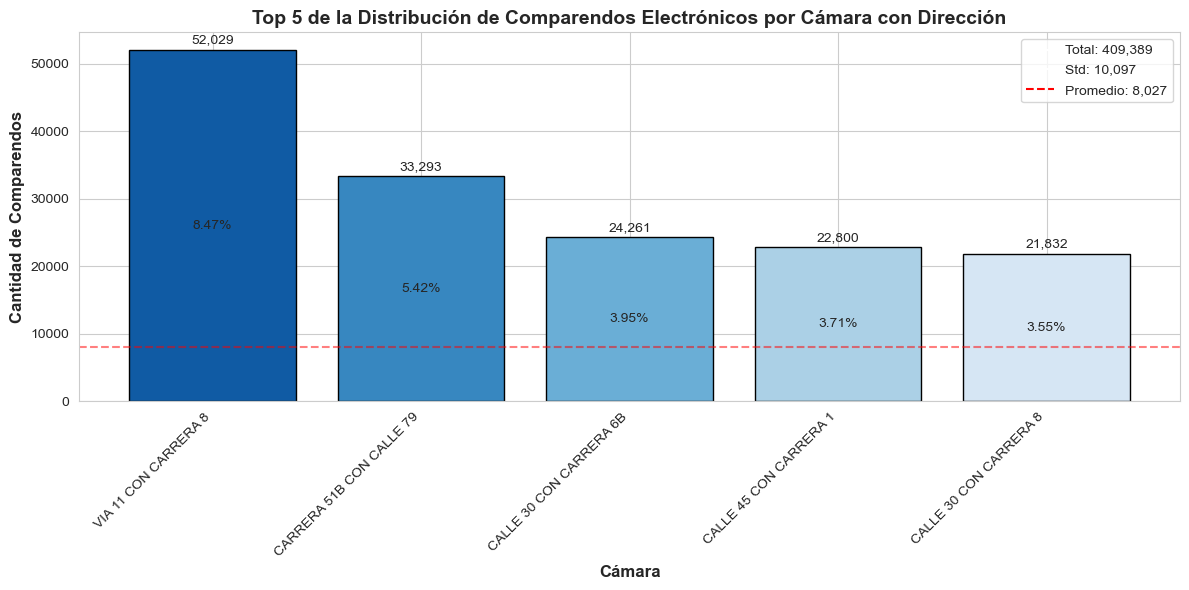

In [931]:
total_direccion = categorias_direccion['Comparendos'].sum()
desviacion_direccion = categorias_direccion['Comparendos'].std()
promedio_direccion = categorias_direccion['Comparendos'].mean()

top_5_direccion = categorias_direccion.head(5)

print("Distribución de Comparendos Electrónicos por Cámara con Dirección")
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(categorias_direccion.T)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

display(HTML("<hr style='border: 1px solid #d3d3d3; margin: 20px 0;'>"))

sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

colors = sns.color_palette("Blues", n_colors=len(top_5_direccion))
colors = colors[::-1]

bars = plt.bar(range(len(top_5_direccion)), top_5_direccion['Comparendos'], color=colors, edgecolor='black', linewidth=1)

plt.title('Top 5 de la Distribución de Comparendos Electrónicos por Cámara con Dirección', fontsize=14, fontweight='bold')
plt.xlabel('Cámara', fontsize=12, fontweight='bold')
plt.ylabel('Cantidad de Comparendos', fontsize=12, fontweight='bold')
plt.xticks(range(len(top_5_direccion)), top_5_direccion['Cámara y Dirección'], fontsize=10, rotation=45, ha='right')

for i, (bar, conteo, porcentaje) in enumerate(zip(bars, top_5_direccion['Comparendos'], top_5_direccion['Porcentaje'])):
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + (max(top_5_direccion['Comparendos'])*0.01),
             f'{int(conteo):,}', ha='center', va='bottom', fontsize=10)
    plt.text(bar.get_x() + bar.get_width()/2., bar.get_height()/2,
             f'{porcentaje}%', ha='center', va='center', fontsize=10)

plt.axhline(y=promedio_direccion, color='red', linestyle='--', alpha=0.5)

plt.legend(loc='upper right', handles=[
    plt.Line2D([0], [0], color='white', label=f'Total: {int(total_direccion):,}'),
    plt.Line2D([0], [0], color='white', label=f'Std: {int(desviacion_direccion):,}'),
    plt.Line2D([0], [0], color='red', linestyle='--', label=f'Promedio: {int(promedio_direccion):,}')
])

plt.tight_layout()
plt.show()

**Análisis de concentración:**

1. **Alta concentración en primeras ubicaciones**:
   - Las primeras 10 cámaras concentran el **60.42%** del total de infracciones.
   - Las primeras 5 cámaras representan el **42.68%** del total.

2. **Cámaras de "Carro mal parqueo"**:
   - Las ubicaciones con denominación "Carro mal parqueo" (Sur, Norte, Sur - Norte) aparecen en las posiciones 1, 2 y 4.
   - En conjunto, estas tres cámaras suman **176,843 infracciones**, equivalentes al **28.78%** del total.

3. **Distribución geográfica**:
   - Las ubicaciones con mayor número de comparendos incluyen corredores viales importantes como:
     - VIA 11 CON CARRERA 8
     - CARRERA 51B CON CALLE 79 y 103
     - CALLE 30 CON CARRERA 6B y 8
     - CALLE 45 CON CARRERA 1
     - CARRERA 53 CON CALLE 104
     - CALLE 82 CON CARRERA 51B

4. **Cola larga**:
   - Las cámaras desde la posición 11 hasta la 56 presentan porcentajes decrecientes, desde 2.78% hasta valores cercanos al 0%.

---

**Comparación con el promedio:**

- **Carro mal parqueo Sur (73,544)**: Supera el promedio en más de 6.7 veces.
- **Carro mal parqueo Norte (65,306)**: Supera el promedio en casi 6 veces.
- **VIA 11 CON CARRERA 8 (52,029)**: Supera el promedio en 4.7 veces.
- **Carro mal parqueo Sur - Norte (37,993)**: Supera el promedio en 3.5 veces.
- **CARRERA 51B CON CALLE 79 (33,293)**: Supera el promedio en 3 veces.
- Las 18 primeras cámaras superan el promedio, mientras que las 38 restantes se encuentran por debajo.

Los recursos de control y vigilancia podrían optimizarse manteniendo el enfoque en los puntos críticos identificados. Además, las cámaras con muy baja participación podrían evaluarse para determinar si su ubicación es estratégica o si requieren mantenimiento o reubicación.

### Análisis temporal de comparendos electrónicos por año

Se examina la evolución anual de los comparendos electrónicos, agrupando los registros por año de la fecha del comparendo y sumando la columna `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada período. Se presentan los resultados mediante una tabla de frecuencias que muestra la cantidad y el porcentaje de infracciones por año, y un gráfico de barras que ilustra la tendencia temporal. Este análisis permite identificar patrones de crecimiento o disminución en la detección de infracciones a lo largo del tiempo, así como evaluar el impacto de la implementación del sistema de cámaras en diferentes años.

In [932]:
infracciones_por_año = df_comparendos_electronicos.groupby(df_comparendos_electronicos['fecha_comparendo'].dt.year)['CANTIDAD_INFRACCIONES'].sum().sort_index()

total_infracciones = df_comparendos_electronicos['CANTIDAD_INFRACCIONES'].sum()
promedio_anual = infracciones_por_año.mean()
max_anual = infracciones_por_año.max()
max_año = infracciones_por_año.idxmax()
min_anual = infracciones_por_año.min()
min_año = infracciones_por_año.idxmin()

df_anual = pd.DataFrame({
    'Año': infracciones_por_año.index,
    'Infracciones': infracciones_por_año.values,
    'Porcentaje del Total': (infracciones_por_año.values / total_infracciones * 100).round(2)
}).sort_values('Infracciones', ascending=False).reset_index(drop=True)

print("Distribución de Comparendos Electrónicos por Año")
display(df_anual)

display(HTML("<hr style='border: 1px solid #d3d3d3; margin: 20px 0;'>"))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=infracciones_por_año.index,
    y=infracciones_por_año.values,
    mode='lines+markers',
    name='Infracciones anuales',
    line=dict(color="blue", width=2),
    marker=dict(size=8, color='blue'),
    hovertemplate='Año: %{x}<br>Infracciones: %{y:,.0f}<extra></extra>',
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='none',
    name=f'Total: {int(total_infracciones):,}',
    showlegend=True
))

x_min = infracciones_por_año.index.min()
x_max = infracciones_por_año.index.max()
fig.add_trace(go.Scatter(
    x=[x_min, x_max],
    y=[promedio_anual, promedio_anual],
    mode='lines',
    name=f'Promedio: {int(promedio_anual):,}',
    line=dict(color='red', width=1.5, dash='dot'),
    showlegend=True,
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[max_año],
    y=[max_anual],
    mode='markers',
    name=f'Máximo: {max_año} ({int(max_anual):,})',
    marker=dict(size=10, color='red', symbol='circle'),
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[min_año],
    y=[min_anual],
    mode='markers',
    name=f'Mínimo: {min_año} ({int(min_anual):,})',
    marker=dict(size=10, color='green', symbol='circle'),
    hoverinfo='none'
))

fig.update_layout(
    title=dict(
        text='Evolución Anual de Comparendos Electrónicos',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Año',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Cantidad de Comparendos',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        x=1, 
        y=1, 
        xanchor='center',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.5)',
        font=dict(size=12)
    ),
    width=1050, 
    height=500
)

fig.update_xaxes(tickmode='linear', tick0=2018, dtick=1)

fig.show()

Distribución de Comparendos Electrónicos por Año


,Año,Infracciones,Porcentaje del Total
0,2019,98171,15.98
1,2023,88402,14.39
2,2024,87994,14.32
3,2018,83741,13.63
4,2022,80415,13.09
5,2020,59526,9.69
6,2025,59198,9.64
7,2021,56915,9.26


**Análisis por períodos:**

1. **Año de mayor detección (2019)**:
   - **2019** registra el mayor volumen con 98,171 infracciones (15.98% del total), posicionándose como el año con mayor actividad de detección del período analizado.

2. **Años de recuperación post-pandemia (2022-2024)**:
   - **2023** y **2024** presentan volúmenes muy similares (88,402 y 87,994 respectivamente), ubicándose en segundo y tercer lugar.
   - **2022** registra 80,415 infracciones (13.09%), ocupando el quinto lugar.
   - Estos tres años(2022-2024) concentran el **41.80%** del total de infracciones.

3. **Años de menor detección (2020, 2021 y 2025)**:
   - **2021** presenta el valor más bajo del período con 56,915 infracciones (9.26%).
   - **2020** registra 59,526 infracciones (9.69%), ubicándose como el segundo año con menor volumen.
   - **2025** presenta 59,198 infracciones (9.64%), con un volumen similar al de 2020. Las posibles causas de este descenso serán analizadas en en análisis posteriores.

---

**Análisis de tendencias:**

1. **Impacto de la pandemia (2020-2021)**:
   - En Colombia, las restricciones de movilidad más estrictas por la pandemia de COVID-19 se implementaron principalmente durante **2020**, con confinamientos obligatorios y medidas de distanciamiento social.
   - A pesar de ello, **2021 presenta el volumen más bajo de infracciones**, incluso inferior a 2020. Este comportamiento podría explicarse por:
      - Cambios en los patrones de movilidad post-pandemia.
      - Posible ajustes en el funcionamiento del sistema de cámaras durante ese período.
   - La reducción de 2019 a 2021 es del **42%** (de 98,171 a 56,915 infracciones).

2. **Recuperación progresiva (2022-2024)**:
   - A partir de 2022, los volúmenes se recuperan y se estabilizan en niveles superiores a 80,000 infracciones anuales.
   - El incremento de 2021 a 2022 es del **41.3%**, reflejando la reactivación total de la movilidad.

3. **Comportamiento de 2025**:
   - El año 2025 presenta 59,198 infracciones, un volumen inferior al de 2023 y 2024, y similar al de 2020.
   - Dado que el año se encuentra completo en la base de datos, este descenso no se debe a datos parciales. Las posibles causas serán exploradas en el análisis bivariado.

---

**Comparación con el promedio anual:**

- **2019 (98,171)**: Supera el promedio en 21,376 infracciones (+27.8%).
- **2023 (88,402)**: Supera el promedio en 11,607 infracciones (+15.1%).
- **2024 (87,994)**: Supera el promedio en 11,199 infracciones (+14.6%).
- **2018 (83,741)**: Supera el promedio en 6,946 infracciones (+9.0%).
- **2022 (80,415)**: Supera el promedio en 3,620 infracciones (+4.7%).
- **2020 (59,526)**: Se encuentra por debajo del promedio (-22.5%).
- **2025 (59,198)**: Se encuentra por debajo del promedio (-22.9%).
- **2021 (56,915)**: Se encuentra por debajo del promedio (-25.9%).

### Análisis temporal de comparendos electrónicos por mes

Se examina la evolución mensual de los comparendos electrónicos a lo largo del período comprendido entre 2018 y 2025, agregando los registros por año-mes y sumando la columna `CANTIDAD_INFRACCIONES` para obtener el volumen real de infracciones por cada período mensual. Se presentan los resultados mediante una tabla de frecuencias que muestra la cantidad y el porcentaje de infracciones por cada mes, y un gráfico de líneas interactivo que ilustra la tendencia temporal con marcadores destacados para los valores máximo y mínimo. Este análisis permite identificar patrones estacionales, detectar cambios significativos en la detección de infracciones a nivel mensual y evaluar el impacto de eventos específicos en la movilidad y el comportamiento de los conductores.

In [933]:
df_comparendos_electronicos_copy = df_comparendos_electronicos.copy()

df_comparendos_electronicos_copy['año_mes'] = df_comparendos_electronicos_copy['fecha_comparendo'].dt.to_period('M').astype(str)

infracciones_por_mes = df_comparendos_electronicos_copy.groupby('año_mes')['CANTIDAD_INFRACCIONES'].sum().sort_index()

promedio_mensual = infracciones_por_mes.mean()
max_mensual = infracciones_por_mes.max()
max_mes = infracciones_por_mes.idxmax()
min_mensual = infracciones_por_mes.min()
min_mes = infracciones_por_mes.idxmin()

df_mensual = pd.DataFrame({
    'Año-Mes': infracciones_por_mes.index,
    'Comparendos': infracciones_por_mes.values,
    'Porcentaje': (infracciones_por_mes.values / total_infracciones * 100).round(2)
}).sort_values('Comparendos', ascending=False).reset_index(drop=True)

print("Distribución de Comparendos Electrónicos por Mes")
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(df_mensual.T)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

display(HTML("<hr style='border: 1px solid #d3d3d3; margin: 20px 0;'>"))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=infracciones_por_mes.index,
    y=infracciones_por_mes.values,
    mode='lines+markers',
    line=dict(color='blue', width=2),
    marker=dict(size=4, color='blue'),
    hovertemplate='Mes: %{x}<br>Infracciones: %{y:,.0f}<extra></extra>',
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='none',
    name=f'Total: {int(total_infracciones):,}',
    showlegend=True
))

x_min = infracciones_por_mes.index[0]
x_max = infracciones_por_mes.index[-1]
fig.add_trace(go.Scatter(
    x=[x_min, x_max],
    y=[promedio_mensual, promedio_mensual],
    mode='lines',
    name=f'Promedio: {int(promedio_mensual):,}',
    line=dict(color='red', width=1.5, dash='dot'),
    showlegend=True,
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[max_mes],
    y=[max_mensual],
    mode='markers',
    name=f'Máximo: {max_mes} ({int(max_mensual):,})',
    marker=dict(size=8, color='red', symbol='circle'),
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[min_mes],
    y=[min_mensual],
    mode='markers',
    name=f'Mínimo: {min_mes} ({int(min_mensual):,})',
    marker=dict(size=8, color='green', symbol='circle'),
    hoverinfo='none'
))

fig.update_layout(
    title=dict(
        text='Evolución Mensual de Comparendos Electrónicos',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Año-Mes',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Cantidad de Comparendos',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        x=1, 
        y=1, 
        xanchor='center',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.5)',
        font=dict(size=12)
    ),
    width=1130,
    height=550
)

meses = infracciones_por_mes.index.tolist()
tick_positions = meses[::6]

fig.update_xaxes(
    tickangle=-45,
    tickvals=tick_positions,
    ticktext=tick_positions
)

fig.show()

Distribución de Comparendos Electrónicos por Mes


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95
Año-Mes,2019-05,2019-06,2019-03,2019-04,2019-07,2024-05,2023-07,2023-09,2024-04,2019-08,2023-12,2022-12,2022-06,2023-08,2023-10,2018-01,2024-03,2024-06,2023-06,2018-11,2019-02,2024-07,2022-05,2023-05,2022-07,2023-03,2024-09,2022-11,2018-10,2023-11,2020-01,2018-03,2024-10,2024-01,2018-05,2023-04,2019-10,2018-12,2020-02,2024-02,2019-09,2022-10,2019-12,2020-10,2018-04,2022-04,2022-09,2021-02,2024-08,2019-11,2019-01,2018-06,2025-10,2018-02,2018-07,2018-09,2018-08,2021-03,2020-12,2022-08,2021-01,2020-03,2023-02,2020-11,2024-11,2025-04,2025-11,2022-03,2025-01,2024-12,2025-03,2025-09,2021-04,2025-05,2022-01,2020-09,2021-07,2025-07,2025-02,2021-12,2020-04,2025-06,2025-12,2020-08,2021-09,2021-08,2021-10,2021-11,2021-05,2022-02,2025-08,2021-06,2020-06,2020-07,2023-01,2020-05
Comparendos,9843,9520,9505,9375,9321,8827,8754,8684,8605,8596,8571,8442,8417,8380,8278,8134,8120,8101,8043,7952,7928,7820,7736,7713,7659,7597,7575,7570,7468,7435,7347,7333,7309,7283,7173,7138,7123,7082,6989,6965,6939,6931,6922,6890,6871,6836,6770,6688,6572,6571,6528,6509,6471,6438,6338,6275,6168,6166,6154,6128,5836,5831,5703,5615,5523,5521,5331,5328,5296,5294,5157,5011,4872,4862,4856,4843,4839,4801,4737,4684,4400,4313,4289,4289,4241,4217,4166,4056,3974,3742,3409,3176,2976,2806,2106,1386
Porcentaje,1.6,1.55,1.55,1.53,1.52,1.44,1.42,1.41,1.4,1.4,1.4,1.37,1.37,1.36,1.35,1.32,1.32,1.32,1.31,1.29,1.29,1.27,1.26,1.26,1.25,1.24,1.23,1.23,1.22,1.21,1.2,1.19,1.19,1.19,1.17,1.16,1.16,1.15,1.14,1.13,1.13,1.13,1.13,1.12,1.12,1.11,1.1,1.09,1.07,1.07,1.06,1.06,1.05,1.05,1.03,1.02,1.0,1.0,1.0,1.0,0.95,0.95,0.93,0.91,0.9,0.9,0.87,0.87,0.86,0.86,0.84,0.82,0.79,0.79,0.79,0.79,0.79,0.78,0.77,0.76,0.72,0.7,0.7,0.7,0.69,0.69,0.68,0.66,0.65,0.61,0.55,0.52,0.48,0.46,0.34,0.23


**Análisis de tendencias:**

1. **Pico máximo en mayo de 2019 (9,843 infracciones)**:
   - Este mes representa el punto más alto de todo el período analizado.
   - Coincide con el año de mayor detección (2019), antes de las restricciones por la pandemia.

2. **Concentración de meses altos en 2019**:
   - De los 10 meses con mayor número de infracciones, **6 corresponden a 2019** (mayo, junio, marzo, abril, julio y agosto).
   - Esto confirma que 2019 fue el año de mayor actividad en la detección de infracciones.

3. **Meses altos en 2023 y 2024**:
   - Los meses de 2023 y 2024 también aparecen en el top 10 (2024-05, 2023-07, 2023-09, 2024-04), mostrando una recuperación sostenida post-pandemia.

4. **Mínimo histórico en mayo de 2020 (1,386 infracciones)**:
   - Este mes registra el valor más bajo de todo el período, con una reducción del **85.9%** respecto al máximo de mayo de 2019.
   - Mayo de 2020 coincide con el período de confinamiento estricto en Colombia debido a la pandemia de COVID-19.

5. **Meses bajos durante 2020 y 2021**:
   - Los meses con menores volúmenes se concentran en 2020 y 2021, reflejando el impacto de las restricciones de movilidad y posibles cambios en el sistema de foto-detección.
   - Destacan también valores bajos en 2021 (marzo, abril, mayo, junio, entre otros) y en los primeros meses de 2025.

---

**Patrones estacionales observados:**

1. **Comportamiento de 2019**:
   - Los meses de mayor actividad se concentran en el primer semestre (marzo a julio), con un pico en mayo.
   - Agosto y septiembre también muestran valores altos, aunque ligeramente inferiores.

2. **Comportamiento post-pandemia (2022-2024)**:
   - Se observa una recuperación con valores mensuales que oscilan entre 6,000 y 8,800 infracciones.
   - Los meses de mayo, julio y septiembre muestran picos recurrentes en este período.

3. **Comportamiento de 2025**:
   - Los meses de 2025 presentan valores considerablemente más bajos (entre 2,000 y 5,500 infracciones).
   - El último mes registrado (2025-12) muestra 2,106 infracciones, uno de los valores más bajos del período.

---

**Comparación con el promedio mensual (6,399):**

- **Meses por encima del promedio**: 39 meses (principalmente 2018-2019 y 2022-2024)
- **Meses por debajo del promedio**: 57 meses (principalmente 2020-2021 y 2025)

In [934]:
df_comparendos_electronicos_copy['mes_nombre'] = df_comparendos_electronicos_copy['fecha_comparendo'].dt.month

nombres_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 
                 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']

df_boxplot = df_comparendos_electronicos_copy.groupby(['mes_nombre', df_comparendos_electronicos_copy['fecha_comparendo'].dt.year])['CANTIDAD_INFRACCIONES'].sum().reset_index()
df_boxplot.columns = ['mes', 'año', 'infracciones']

df_boxplot['mes_nombre'] = df_boxplot['mes'].apply(lambda x: nombres_meses[x-1])

print("Estadísticas Descriptivas por Mes")
estadisticas_mensuales = df_boxplot.groupby('mes_nombre')['infracciones'].describe().round(0).astype(int).reindex(nombres_meses)
display(estadisticas_mensuales.T)

display(HTML("<hr style='border: 1px solid #d3d3d3; margin: 20px 0;'>"))

fig = go.Figure()

fig.add_trace(go.Box(
    x=df_boxplot['mes_nombre'],
    y=df_boxplot['infracciones'],
    marker_color='blue',
    name='', 
    boxmean=True,
    hovertemplate='Mes: %{x}<br>Infracciones: %{y:,.0f}<extra></extra>'
))

fig.update_layout(
    title=dict(
        text='Distribución de Comparendos Electrónicos por Mes',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Mes',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Cantidad de Comparendos',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    width=1130,
    height=550
)

fig.show()

Estadísticas Descriptivas por Mes


mes_nombre,Enero,Febrero,Marzo,Abril,Mayo,Junio,Julio,Agosto,Septiembre,Octubre,Noviembre,Diciembre
count,8,8,8,8,8,8,8,8,8,8,8,8
mean,5923,6149,6880,6702,6439,6382,6542,5970,6292,6830,6257,6430
std,1899,1357,1518,1734,2809,2560,2250,1912,1510,1199,1349,1617
min,2106,3742,5157,4400,1386,2976,2806,3409,4241,4166,4056,4289
25%,5186,5462,5705,5359,4640,4029,4830,4271,4969,6785,5475,5142
50%,6182,6563,6750,6854,7443,7276,6998,6148,6522,7027,6093,6538
75%,7299,6971,7728,7505,8009,8180,8054,7024,7098,7349,7469,7422
max,8134,7928,9505,9375,9843,9520,9321,8596,8684,8278,7952,8571


In [935]:
df_comparendos_electronicos_copy['año'] = df_comparendos_electronicos_copy['fecha_comparendo'].dt.year
df_comparendos_electronicos_copy['mes'] = df_comparendos_electronicos_copy['fecha_comparendo'].dt.month

tabla_heatmap = df_comparendos_electronicos_copy.pivot_table(
    values='CANTIDAD_INFRACCIONES',
    index='mes',
    columns='año',
    aggfunc='sum',
    fill_value=0
)

tabla_heatmap.index = nombres_meses

fig = go.Figure(data=go.Heatmap(
    z=tabla_heatmap.values,
    x=tabla_heatmap.columns,
    y=tabla_heatmap.index,
    colorscale='blues',
    text=tabla_heatmap.values,
    texttemplate='%{text:,.0f}',
    hovertemplate='Mes: %{y}<br>Año: %{x}<br>Infracciones: %{z:,.0f}<extra></extra>'
))

fig.update_layout(
    title=dict(
        text='Comparendos Electrónicos por Año y Mes',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Año',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Mes',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    width=1130,
    height=550
)

fig.show()

In [936]:
df_comparendos_electronicos_copy['año_mes_semana'] = df_comparendos_electronicos_copy['fecha_comparendo'].dt.strftime('%Y-%m-W%W')

infracciones_por_semana = df_comparendos_electronicos_copy.groupby('año_mes_semana')['CANTIDAD_INFRACCIONES'].sum().sort_index()

promedio_semanal = infracciones_por_semana.mean()
max_semanal = infracciones_por_semana.max()
max_semana = infracciones_por_semana.idxmax()
min_semanal = infracciones_por_semana.min()
min_semana = infracciones_por_semana.idxmin()

df_semanal = pd.DataFrame({
    'Año-Mes-Semana': infracciones_por_semana.index,
    'Infracciones': infracciones_por_semana.values,
    'Porcentaje del Total': (infracciones_por_semana.values / total_infracciones * 100).round(2)
}).sort_values('Infracciones', ascending=False).reset_index(drop=True)

print("Distribución de Comparendos Electrónicos por Semana")
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(df_semanal.T)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

display(HTML("<hr style='border: 1px solid #d3d3d3; margin: 20px 0;'>"))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=infracciones_por_semana.index,
    y=infracciones_por_semana.values,
    mode='lines',
    name='Infracciones semanales',
    line=dict(color='blue', width=1.5),
    hovertemplate='Semana: %{x}<br>Infracciones: %{y:,.0f}<extra></extra>',
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='none',
    name=f'Total: {int(total_infracciones):,}',
    showlegend=True
))

x_min = infracciones_por_semana.index[0]
x_max = infracciones_por_semana.index[-1]
fig.add_trace(go.Scatter(
    x=[x_min, x_max],
    y=[promedio_semanal, promedio_semanal],
    mode='lines',
    name=f'Promedio: {int(promedio_semanal):,}',
    line=dict(color='red', width=1.5, dash='dot'),
    showlegend=True,
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[max_semana],
    y=[max_semanal],
    mode='markers',
    name=f'Máximo: {max_semana} ({int(max_semanal):,})',
    marker=dict(size=8, color='red', symbol='circle'),
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[min_semana],
    y=[min_semanal],
    mode='markers',
    name=f'Mínimo: {min_semana} ({int(min_semanal):,})',
    marker=dict(size=8, color='green', symbol='circle'),
    hoverinfo='none'
))

fig.update_layout(
    title=dict(
        text='Evolución Semanal de Comparendos Electrónicos',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Año-Mes-Semana',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Cantidad de Comparendos',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        x=1, 
        y=1, 
        xanchor='center',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.5)',
        font=dict(size=12)
    ),
    width=1130,
    height=550
)

semanas = infracciones_por_semana.index.tolist()
tick_positions = semanas[::26]

fig.update_xaxes(
    tickangle=-45,
    tickvals=tick_positions,
    ticktext=tick_positions
)

fig.show()

Distribución de Comparendos Electrónicos por Semana


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,374,375,376,377,378,379,380,381,382,383,384,385,386,387,388,389,390,391,392,393,394,395,396,397,398,399,400,401,402,403,404,405,406,407,408,409,410,411,412,413,414,415,416,417,418,419,420,421,422,423,424,425,426,427,428,429,430,431,432,433,434,435,436,437,438,439,440,441,442,443,444,445,446,447,448,449,450,451,452,453,454,455,456,457,458,459,460,461,462,463,464,465,466,467,468,469,470,471,472,473,474,475,476,477,478,479,480,481,482,483,484,485,486,487,488,489,490,491,492,493,494,495
Año-Mes-Semana,2019-06-W23,2024-09-W39,2019-05-W19,2019-06-W22,2023-07-W30,2019-04-W16,2019-05-W18,2024-04-W16,2019-04-W15,2019-03-W11,2019-07-W28,2023-12-W51,2019-04-W14,2019-07-W27,2019-07-W26,2024-05-W19,2022-12-W51,2019-03-W09,2019-06-W24,2024-04-W17,2022-06-W23,2024-05-W20,2022-04-W15,2023-09-W36,2019-03-W10,2022-12-W50,2023-10-W40,2019-05-W20,2024-03-W12,2019-02-W07,2019-08-W31,2019-04-W13,2019-06-W25,2022-12-W49,2022-11-W47,2023-12-W49,2019-03-W12,2019-07-W29,2024-06-W25,2022-06-W24,2022-06-W25,2023-07-W28,2024-06-W26,2023-09-W38,2018-01-W01,2018-10-W43,2023-07-W29,2019-08-W33,2023-06-W24,2024-02-W06,2024-03-W11,2023-06-W23,2024-07-W28,2019-02-W06,2023-09-W37,2024-05-W21,2023-06-W25,2023-10-W43,2018-11-W47,2023-08-W31,2023-09-W39,2023-12-W50,2023-05-W19,2023-03-W11,2019-02-W05,2023-05-W21,2019-01-W00,2022-07-W27,2024-06-W24,2023-07-W27,2023-10-W42,2021-01-W04,2018-01-W04,2024-04-W15,2022-05-W19,2024-03-W13,2018-11-W45,2024-09-W37,2024-04-W14,2021-02-W05,2023-08-W32,2023-08-W33,2018-12-W49,2024-07-W27,2018-03-W11,2018-01-W02,2022-09-W38,2024-01-W04,2019-09-W35,2023-04-W14,2022-05-W20,2023-11-W45,2018-02-W08,2018-01-W03,2018-12-W50,2018-06-W23,2020-02-W07,2023-12-W52,2018-05-W19,2024-06-W23,2023-04-W15,2018-11-W46,2022-07-W30,2023-11-W47,2024-02-W08,2019-05-W21,2022-10-W43,2024-07-W30,2022-05-W21,2019-12-W51,2022-07-W28,2019-08-W32,2020-02-W06,2024-03-W10,2023-02-W07,2020-01-W01,2023-10-W41,2018-03-W10,2023-05-W18,2023-03-W12,2024-01-W03,2024-10-W42,2022-11-W46,2023-03-W10,2019-10-W40,2018-04-W16,2021-02-W06,2020-02-W05,2022-05-W18,2020-03-W10,2021-02-W08,2023-05-W20,2020-10-W42,2023-08-W34,2018-10-W42,2020-01-W03,2019-10-W41,2019-09-W37,2019-09-W36,2023-04-W17,2022-10-W42,2019-11-W45,2018-04-W17,2020-10-W41,2022-07-W29,2019-08-W34,2022-04-W14,2024-08-W32,2019-12-W49,2018-12-W52,2018-02-W06,2018-03-W12,2018-04-W14,2021-03-W09,2018-10-W40,2023-11-W46,2025-11-W45,2018-09-W39,2018-04-W15,2024-09-W38,2023-04-W16,2021-02-W07,2020-01-W02,2022-10-W40,2024-01-W01,2024-10-W41,2024-01-W02,2024-10-W43,2018-05-W21,2020-10-W40,2019-12-W50,2022-09-W37,2018-08-W32,2018-07-W30,2024-07-W29,2018-06-W2

In [937]:
infracciones_por_dia = df_comparendos_electronicos_copy.groupby('fecha_comparendo')['CANTIDAD_INFRACCIONES'].sum().sort_index()

promedio_diario = infracciones_por_dia.mean()
max_diario = infracciones_por_dia.max()
max_dia = infracciones_por_dia.idxmax()
min_diario = infracciones_por_dia.min()
min_dia = infracciones_por_dia.idxmin()


df_diario = pd.DataFrame({
    'Fecha': infracciones_por_dia.index,
    'Infracciones': infracciones_por_dia.values,
    'Porcentaje del Total': (infracciones_por_dia.values / total_infracciones * 100).round(2)
}).sort_values('Infracciones', ascending=False).reset_index(drop=True)

print("Distribución de Comparendos Electrónicos por Día")
pd.set_option('display.max_columns', None)  
pd.set_option('display.width', None)        
pd.set_option('display.max_colwidth', None) 
display(df_diario.T)
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

display(HTML("<hr style='border: 1px solid #d3d3d3; margin: 20px 0;'>"))

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=infracciones_por_dia.index,
    y=infracciones_por_dia.values,
    mode='lines',
    name='Infracciones diarias',
    line=dict(color='blue', width=1),
    hovertemplate='Fecha: %{x}<br>Infracciones: %{y:,.0f}<extra></extra>',
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='none',
    name=f'Total: {int(total_infracciones):,}',
    showlegend=True
))

x_min = infracciones_por_dia.index[0]
x_max = infracciones_por_dia.index[-1]
fig.add_trace(go.Scatter(
    x=[x_min, x_max],
    y=[promedio_diario, promedio_diario],
    mode='lines',
    name=f'Promedio diario: {int(promedio_diario):,}',
    line=dict(color='red', width=1.5, dash='dot'),
    showlegend=True,
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[max_dia],
    y=[max_diario],
    mode='markers',
    name=f'Máximo: {max_dia} ({int(max_diario):,})',
    marker=dict(size=8, color='red', symbol='circle'),
    hoverinfo='none'
))

fig.add_trace(go.Scatter(
    x=[min_dia],
    y=[min_diario],
    mode='markers',
    name=f'Mínimo: {min_dia} ({int(min_diario):,})',
    marker=dict(size=8, color='green', symbol='circle'),
    hoverinfo='none'
))

fig.update_layout(
    title=dict(
        text='Evolución Diaria de Comparendos Electrónicos',
        x=0.5,
        xanchor='center',
        font=dict(size=16, weight='bold')
    ),
    xaxis_title=dict(
        text='Fecha',
        font=dict(weight='bold')
    ),
    yaxis_title=dict(
        text='Cantidad de Comparendos',
        font=dict(weight='bold')
    ),
    template='plotly_white',
    hovermode='x unified',
    legend=dict(
        x=1, 
        y=1, 
        xanchor='center',
        yanchor='top',
        bgcolor='rgba(255,255,255,0.5)',
        font=dict(size=12)
    ),
    width=1130,
    height=550
)

dias = infracciones_por_dia.index.tolist()
tick_positions = dias[::182]

fig.update_xaxes(
    tickangle=-45,
    tickvals=tick_positions,
    ticktext=[d.strftime('%Y-%m') for d in tick_positions] 
)

fig.show()

Distribución de Comparendos Electrónicos por Día


0                    1     \
Fecha                 2024-09-26 00:00:00  2024-09-25 00:00:00   
Infracciones                          582                  541   
Porcentaje del Total                 0.09                 0.09   

                                     2                    3     \
Fecha                 2023-07-29 00:00:00  2024-04-22 00:00:00   
Infracciones                          456                  440   
Porcentaje del Total                 0.07                 0.07   

                                     4                    5     \
Fecha                 2022-04-15 00:00:00  2019-04-19 00:00:00   
Infracciones                          427                  422   
Porcentaje del Total                 0.07                 0.07   

                                     6                    7     \
Fecha                 2019-05-17 00:00:00  2019-05-30 00:00:00   
Infracciones                          410                  410   
Porcentaje del Total                 0.07                 0.07   

                                     8                    9     \
Fecha                 2019-05-10 00:00:00  2019-07-06 00:00:00   
Infracciones                          409                  404   
Porcentaje del Total                 0.07                 0.07   

                                     10                   11    \
Fecha                 2019-03-05 00:00:00  2024-04-15 00:00:00   
Infracciones                          401                  400   
Porcentaje del Total                 0.07                 0.07   

                                     12                   13    \
Fecha                 2023-07-28 00:00:00  2019-05-15 00:00:00   
Infracciones                          399                  399   
Porcentaje del Total                 0.06                 0.06   

                                     14                   15    \
Fecha                 2019-06-07 00:00:00  2019-07-16 00:00:00   
Infracciones                          397                  396   
Porcentaje del Total                 0.06                 0.06   

                                     16                   17    \
Fecha                 2024-05-10 00:00:00  2022-12-01 00:00:00   
Infracciones                          394                  393   
Porcentaje del Total                 0.06                 0.06   

                                     18                   19    \
Fecha                 2019-05-07 00:00:00  2024-05-14 00:00:00   
Infracciones                          390                  389   
Porcentaje del Total                 0.06                 0.06   

                                     20                   21    \
Fecha                 2019-05-09 00:00:00  2019-05-18 00:00:00   
Infracciones                          387                  386   
Porcentaje del Total                 0.06                 0.06   

                                     22                   23    \
Fecha                 2019-02-21 00:00:00  2022-11-25 00:00:00   
Infracciones                          386                  385   
Porcentaje del Total                 0.06                 0.06   

                                     24                   25    \
Fecha                 2019-06-14 00:00:00  2019-06-06 00:00:00   
Infracciones                          385                  383   
Porcentaje del Total                 0.06                 0.06   

                                     26                   27    \
Fecha                 2019-02-28 00:00:00  2019-03-01 00:00:00   
Infracciones                          381                  380   
Porcentaje del Total                 0.06                 0.06   

                                     28                   29    \
Fecha                 2024-04-23 00:00:00  2019-06-13 00:00:00   
Infracciones                          379                  379   
Porcentaje del Total                 0.06                 0.06   

                                     30                   31  